In [108]:
import io
import os
import fnmatch
from typing import Optional
import paramiko
import pandas as pd

def fetch_and_concat_csvs(
    ip: str,
    user: str,
    password: str,
    remote_dir: str,
    pattern: str = "df_metrics*",
    port: int = 22,
    return_csv_string: bool = False,
    timeout: Optional[float] = 10.0,
) -> pd.DataFrame:
    """
    Se connecte en SFTP et télécharge/télécharge en mémoire tous les fichiers
    du dossier `remote_dir` qui correspondent au `pattern` (fnmatch), lit les CSV,
    ajoute une colonne 'file' contenant le nom du fichier, concatène et renvoie
    le DataFrame final.

    Paramètres
    ----------
    ip, user, password : str
        Informations de connexion SSH.
    remote_dir : str
        Dossier distant à parcourir (chemin absolu ou relatif à l'utilisateur SFTP).
    pattern : str
        Pattern shell-style (ex: 'df_metrics*').
    port : int
        Port SSH (par défaut 22).
    return_csv_string : bool
        Si True, renvoie une tuple (DataFrame, csv_string). Sinon seulement DataFrame.
    timeout : float|None
        Timeout connexion en secondes.

    Retour
    ------
    pd.DataFrame
        DataFrame pandas concaténé contenant tous les enregistrements et une colonne 'file'.
        (ou (DataFrame, csv_string) si return_csv_string=True)
    """

    # Prépare le client SSH / SFTP
    transport = None
    sftp = None
    try:
        # Connexion SSH (transport)
        transport = paramiko.Transport((ip, port))
        transport.connect(username=user, password=password)
        # Ouvrir SFTP
        sftp = paramiko.SFTPClient.from_transport(transport)

        # Lister fichiers dans le répertoire distant
        try:
            files = sftp.listdir(remote_dir)
        except IOError:
            # Peut-être remote_dir non trouvé ; relancer en absolu ou lever l'erreur
            raise

        # Filtrer par pattern
        matched = [f for f in files if fnmatch.fnmatch(f, pattern)]
        if not matched:
            # Aucun fichier trouvé : renvoyer DataFrame vide
            empty_df = pd.DataFrame()
            if return_csv_string:
                return empty_df, ""
            return empty_df

        dfs = []
        for fname in matched:
            print(fname)
            if ('GRU' not in fname and 'LSTM' not in fname and 'MLP' not in fname and 'student' not in fname) and 'wk' not in fname:
                continue
            print(fname)
            #if 'tree' not in fname:
            #    continue
            remote_path = os.path.join(remote_dir, fname)
            # Ouvre en binaire, lit tout en mémoire
            with sftp.open(remote_path, "rb") as remote_file:
                raw = remote_file.read()
            # Tenter de lire avec pandas
            # On essaie d'abord BytesIO (pandas gère souvent les bytes),
            # sinon on décode en utf-8 en tolérant les erreurs.
            df = None
            try:
                df = pd.read_csv(io.BytesIO(raw))
            except Exception:
                # try decoding then StringIO
                try:
                    txt = raw.decode("utf-8", errors="replace")
                    df = pd.read_csv(io.StringIO(txt))
                except Exception as e:
                    # En cas d'échec, lever une erreur explicite
                    raise RuntimeError(f"Impossible de parser le CSV distant {remote_path!r}: {e}")

            # Ajouter colonne 'file' avec le nom du fichier (basename)
            df["file"] = os.path.basename(fname)
            dfs.append(df)

        # Concaténer
        final_df = pd.concat(dfs, ignore_index=True, sort=False)

        if return_csv_string:
            csv_str = final_df.to_csv(index=False)
            return final_df, csv_str

        return final_df

    finally:
        # Fermeture propre des connexions
        if sftp is not None:
            try:
                sftp.close()
            except Exception:
                pass
        if transport is not None:
            try:
                transport.close()
            except Exception:
                pass

In [109]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/full_all_departement_0_None_node"

df = fetch_and_concat_csvs(IP, USER, PASSWORD, REMOTE_DIR, pattern="df_metrics*")
print("Lignes totales :", len(df))
print(df.head())

df_metrics_any_config_alafederated_transformer.json.csv
df_metrics_any_config_voting_confidence_distillation_GRU.json.csv
df_metrics_any_config_voting_confidence_distillation_GRU.json.csv
df_metrics_any_config_graphcast.json.csv
df_metrics_any_config_test_C_explore.json.csv
df_metrics_any_config_moonfederated_transformer.json.csv
df_metrics_any_config_test_cewk.json.csv
df_metrics_any_config_test_cewk.json.csv
df_metrics_any_config_BA_root.json.csv
df_metrics_any_config_federated_transformer.json.csv
df_metrics_any_config_voting_relationMLP_distillation_GRU.json.csv
df_metrics_any_config_voting_relationMLP_distillation_GRU.json.csv
df_metrics_any_config_test_esn.json.csv
df_metrics_any_config_graphcast_BA.json.csv
df_metrics_any_config_test_bce.json.csv
df_metrics_any_config_test_C_explore_07.json.csv
df_metrics_any_config_graphcast_test.json.csv
df_metrics_any_config_voting_GRU.json.csv
df_metrics_any_config_voting_GRU.json.csv
df_metrics_any_config_student.json.csv
df_metrics_any_con

In [110]:
def select_metrics(df : pd.DataFrame, metrics : list[str]):
    return df[['Run'] + metrics]

#df = select_metrics(df, ['mean_iou_test', 'mean_f1_test', 'mean_prec_test', 'mean_recall_test', 'mean_normalized_iou_test', \
#                         'mean_normalized_f1_test', 'mean_normalized_prec_test', 'mean_normalized_rec_test', \
#                            'mean_iou_elt_sup_3.0_test', 'mean_f1_elt_sup_3.0_test', 'mean_prec_elt_sup_3.0_test', 'mean_rec_elt_sup_3.0_test'])

In [111]:
def parse_run_name_old(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
    else:
        dico['loss'] = None
    
    i += 1
    #dico['Number_of_features'] = vec[i]
    i += 1
    dico['Scale'] = vec[i]
    if 'scale_result' not in dico.keys():
        dico['scale_result'] = vec[i]
    i += 1
    dico['Days_in_futur'] = vec[i]
    i += 1
    dico['Base'] = vec[i]
    i += 1
    dico['Method'] = vec[i]
    i += 1

    if i == len(vec):
        return dico
    if vec[i] == 'kmeans':
        i += 1
        dico['kmeans_shift'] = vec[i]
        i += 1
        dico['kmeans_thresh'] = vec[i]
        i += 1
    return dico
# %%
def parse_run_name_new(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['horizon_train'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        dico['horizon'] = vec[i]
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
    else:
        dico['loss'] = None
    
    return dico

# Initialisation des colonnes avec des valeurs None
df['Department'] = None
df['Model'] = None
df['Target'] = None
df['Task_type'] = None
df['Drop'] = None
df['Loss_function'] = None
df['under_sampling'] = None
df['over_sampling'] = None
df['kdays'] = None
df['horizon'] = None
df['horizon_train'] = None
df['Number_of_features'] = None
df['Scale'] = None
df['Base'] = None
df['Method'] = None
df['Days_in_futur'] = None
df['weight'] = None
df['kmeans_thresh'] = None
df['kmeans_shift'] = None
df['scale_result'] = None

# Boucle pour remplir les colonnes avec les valeurs de dico_parse
for index, row in df.iterrows():
    try:
        dico_parse = parse_run_name_new(row['Run'])
        if dico_parse is None:
            continue
    except:
        continue
    # Mise à jour de chaque colonne avec les valeurs du dictionnaire dico_parse
    df.loc[index, 'Department'] = dico_parse.get('Department')
    df.loc[index, 'scale_result'] = dico_parse.get('scale_result')
    df.loc[index, 'Drop'] = dico_parse.get('Drop')
    df.loc[index, 'Model'] = dico_parse.get('Model')
    df.loc[index, 'Target'] = dico_parse.get('Target')
    df.loc[index, 'Task_type'] = dico_parse.get('Task_type')
    df.loc[index, 'Loss_function'] = dico_parse.get('loss')
    df.loc[index, 'under_sampling'] = dico_parse.get('under_sampling')
    df.loc[index, 'over_sampling'] = dico_parse.get('over_sampling')
    df.loc[index, 'kdays'] = dico_parse.get('kdays')
    df.loc[index, 'horizon'] = dico_parse.get('horizon')
    df.loc[index, 'horizon_train'] = dico_parse.get('horizon_train')
    df.loc[index, 'Number_of_features'] = dico_parse.get('Number_of_features')
    df.loc[index, 'Scale'] = dico_parse.get('Scale')
    df.loc[index, 'Base'] = dico_parse.get('Base')
    df.loc[index, 'Method'] = dico_parse.get('Method')
    df.loc[index, 'Days_in_futur'] = dico_parse.get('Days_in_futur')

    df.loc[index, 'weight'] = dico_parse.get('weight')
    df.loc[index, 'kmeans_thresh'] = dico_parse.get('kmeans_thresh', 0)
    df.loc[index, 'kmeans_shift'] = dico_parse.get('kmeans_shift', 0)

#df['horizon'] = df['horizon'].astype(int)

all_studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node


/tmp/ipykernel_16147/2896652310.py:145: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Department'] = None
/tmp/ipykernel_16147/2896652310.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Model'] = None
/tmp/ipykernel_16147/2896652310.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

all_studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Season_classification_cewk-C1{0.3}_0_10_full_all_departement_0_None_node
all_GRU_search_full_10_0_all_one_burnedareaRoot-egpd-5-Class-Season_classification_cewk-C1{0.3}_0_10_full_all_departement_0_None_node
all_studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_studenML

In [112]:
df

,Unnamed: 0,Run,nbsinister,r2,mse,IV,accuracy,auoc,f1,prec,...,horizon_train,Number_of_features,Scale,Base,Method,Days_in_futur,weight,kmeans_thresh,kmeans_shift,scale_result
0,0,all_studenMLP-Confidence-T3.0-A1.0-B1.0-filter...,2192.0,-0.397743,0.129658,1.73,0.90,0.678,0.408,0.304,...,0,all,None,None,None,None,one,0,0,0
1,1,all_studenMLP-Confidence-T3.0-A1.0-B1.0-filter...,2192.0,-1.039957,0.189232,1.94,0.88,0.667,0.385,0.266,...,0,all,None,None,None,None,one,0,0,0
2,2,all_studenMLP-Confidence-T3.0-A1.0-B1.0-filter...,2192.0,-1.608454,0.241967,2.04,0.84,0.664,0.344,0.223,...,0,all,None,None,None,None,one,0,0,0
3,0,all_GRU_search_full_10_0_all_one_nbsinister-km...,2192.0,-2.730509,0.353112,2.05,0.80,0.571,0.298,0.182,...,0,all,None,None,None,None,one,0,0,0
4,1,all_GRU_search_full_10_0_all_one_burnedareaRoo...,2192.0,-1.221136,0.435440,1.18,0.90,0.687,0.348,0.265,...,0,all,None,None,None,None,one,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,1,all_studenMLP-normal-T3.0-A0.2-filter-GRU-soft...,2192.0,-0.322415,0.122671,1.69,0.91,0.688,0.421,0.325,...,0,all,None,None,None,None,one,0,0,0
85,2,all_studenMLP-normal-T3.0-A0.2-filter-GRU-soft...,2192.0,-0.453433,0.134824,1.65,0.91,0.681,0.422,0.331,...,0,all,None,None,None,None,one,0,0,0
86,0,all_studenMLP-RelationATT-T6.0-A1.0-B1.0-filte...,2192.0,-0.313724,0.121865,1.69,0.90,0.690,0.411,0.309,...,0,all,None,None,None,None,one,0,0,0
87,1,all_studenMLP-RelationATT-T6.0-A1.0-B1.0-filte...,2192.0,-0.682635,0.156086,1.91,0.88,0.655,0.389,0.270,...,0,all,None,None,None,None,one,0,0,0


In [113]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from typing import Optional

def plot_metric_by_loss_param(
    df: pd.DataFrame,
    loss: str,
    metric_col: str,
    *,
    param_key: str = "C",
    model_col: str = "Model",
    loss_col: str = "loss_function",
    ax: Optional[plt.Axes] = None
) -> plt.Axes:
    """
    Trace une courbe par `Model` : metric_col en fonction du paramètre `param_key`,
    pour les lignes dont `loss_col` commence par la loss de base (ex. 'L1', 'L1-C{...}', etc.).
    Le paramètre est extrait d'abord dans loss_col, puis fallback model_col, au format 'param_key{...}'.
    """
    # 0) Colonnes requises
    for c in (metric_col, model_col, loss_col):
        if c not in df.columns:
            raise KeyError(f"Colonne manquante: '{c}'")

    # 1) Filtrer par loss de base
    base_mask = df[loss_col].astype(str).str.match(rf'^{re.escape(loss)}(?:$|[-{{])', na=False)
    sub = df.loc[base_mask, [model_col, loss_col, metric_col]].copy()
    if sub.empty:
        raise ValueError(f"Aucune ligne trouvée dont '{loss_col}' commence par '{loss}'.")

    # 2) Extraire le paramètre dans loss_col puis fallback model_col
    pattern = rf"{re.escape(param_key)}\{{\s*([^}}]+?)\s*\}}"
    param_from_loss  = sub[loss_col].astype(str).str.extract(pattern, expand=False)
    param_from_model = sub[model_col].astype(str).str.extract(pattern, expand=False)
    sub["__param_raw__"] = param_from_loss.where(param_from_loss.notna(), param_from_model)

    if sub["__param_raw__"].isna().all():
        raise ValueError(
            f"Aucun paramètre '{param_key}{{...}}' trouvé dans '{loss_col}' ni '{model_col}' pour la loss '{loss}'."
        )

    # 3) Conversion param -> numérique si possible
    def _to_number(x):
        if pd.isna(x):
            return None
        s = str(x).strip().replace(",", ".")
        try:
            return float(s)
        except ValueError:
            return s  # ex: 'auto', 'cosine'

    sub["param_value"] = sub["__param_raw__"].map(_to_number)
    sub = sub.dropna(subset=["param_value", metric_col]).copy()

    # 4) Agréger (si plusieurs lignes) : moyenne par (Model, param_value)
    agg = (
        sub.groupby([model_col, "param_value"], as_index=False)[metric_col]
        .mean()
    )

    # 5) Déterminer si on est en numérique pur ou non
    is_num = agg["param_value"].map(lambda v: isinstance(v, (int, float)))
    all_numeric = bool(is_num.all())

    if ax is None:
        _, ax = plt.subplots()

    if all_numeric:
        # Courbe par modèle, triée par paramètre
        for m, g in agg.groupby(model_col):
            g = g.sort_values("param_value")
            ax.plot(g["param_value"], g[metric_col], marker="o", linestyle="-", label=str(m))
        ax.set_xlabel(f"{param_key} (paramètre de {loss})")
    else:
        # Axe catégoriel partagé
        # Ordre des catégories : numériquement triées pour les nombres, puis les chaînes par ordre d'apparition.
        nums = sorted(sorted({v for v in agg["param_value"] if isinstance(v, (int, float))}))
        cats = [v for v in agg["param_value"] if not isinstance(v, (int, float))]
        # Conserver l'ordre d'apparition pour les non-numériques
        seen = set()
        cats = [x for x in cats if not (x in seen or seen.add(x))]
        x_levels = nums + cats
        x_index = {v: i for i, v in enumerate(x_levels)}

        for m, g in agg.groupby(model_col):
            g = g.copy()
            g["__x__"] = g["param_value"].map(x_index).astype(float)
            g = g.sort_values("__x__")
            ax.plot(g["__x__"], g[metric_col], marker="o", linestyle="-", label=str(m))
        ax.set_xticks(range(len(x_levels)), [str(x) for x in x_levels])
        ax.set_xlabel(f"{param_key} (catégories/valeurs) — {loss}")

    ax.set_ylabel(metric_col)
    ax.set_title(f"{metric_col} en fonction de {param_key} — loss '{loss}' (une courbe par {model_col})")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(title=model_col, loc="best")

    return ax

In [114]:
#def select_models(df : pd.DataFrame, models : list[str]):
#    return df[df['Model'].isin(models)]

#df = select_models(df, ['GRU'])
#df = df.dropna(subset='mean_iou_test')

In [115]:
df.Loss_function.unique()

array(['wkloss', 'cewk-C1{0.3}', 'weightedcrossentropy'], dtype=object)

In [116]:
#plot_metric_by_loss_param(df, 'mcewk', metric_col='mean_iou_test', param_key='C', loss_col='Loss_function')
#plot_metric_by_loss_param(df, 'mcewk', metric_col='mean_iou_elt_sup_3.0_test', param_key='C', loss_col='Loss_function')
#plot_metric_by_loss_param(df, 'mcewk', metric_col='mean_normalized_iou_test', param_key='C', loss_col='Loss_function')

In [117]:
df = df[(df['Target'].isin(['nbsinister-kmeans-5-Class-Dept', 'nbsinister-gm-5-Class-Season']))]

In [118]:
df.Model.unique()

array(['studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'filter-GRU-soft-weight-1', 'filter-GRU-soft-weight-2',
       'filter-GRU-soft-weight-3', 'filter-GRU-soft-weight-4',
       'filter-GRU-soft-weight-5', 'filter-GRU-soft-weight-6',
       'filter-GRU-soft-weight-7', 'filter-GRU-soft-weight-8',
       'filter-GRU-soft-weight-9', 'filter-GRU-soft-weight-10',
       'filter-GRU-soft-weight-11', 'filter-GRU-soft-weight-12',
       'filter-GRU-soft-weight-13', 'filter-GRU-soft-weight-14',
       'filter-GRU-soft-weight-15', 'filter-GRU-soft-weight-16',
       'filter-GRU-soft-weight-17', 'filter-GRU-soft-w

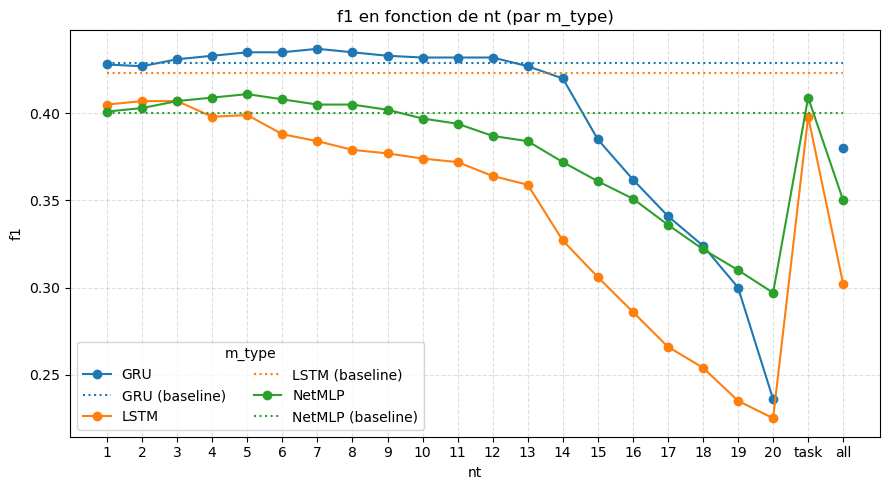

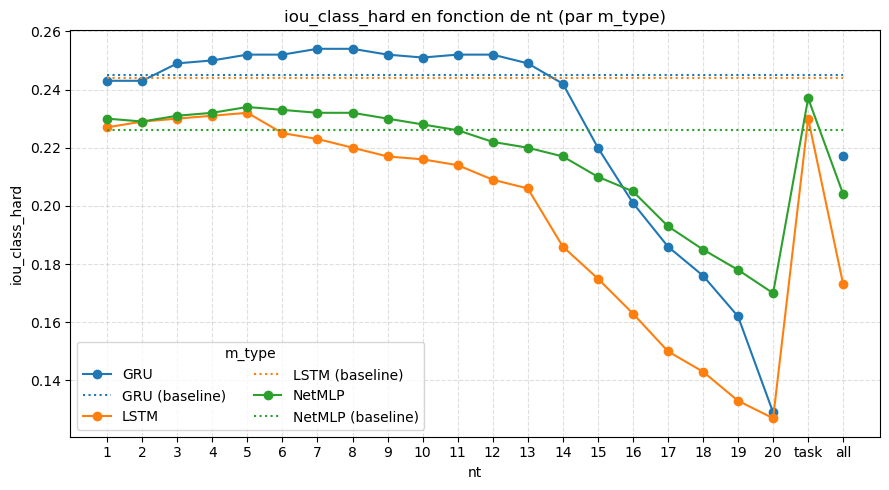

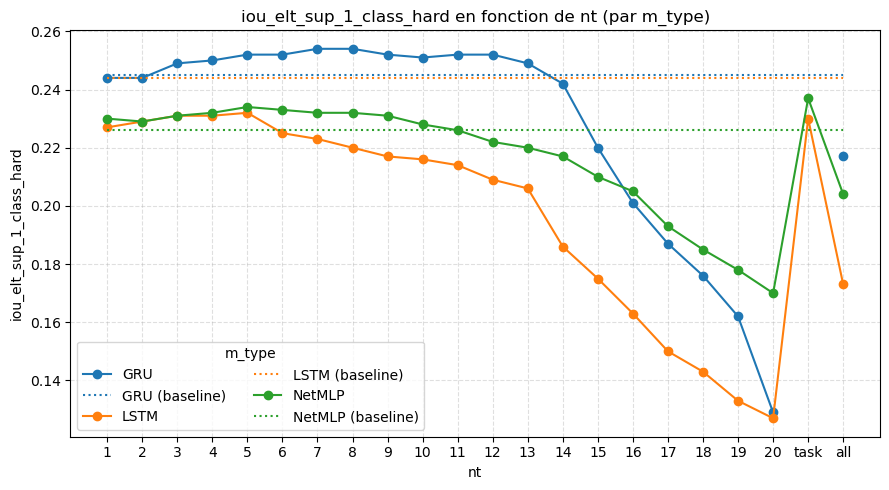

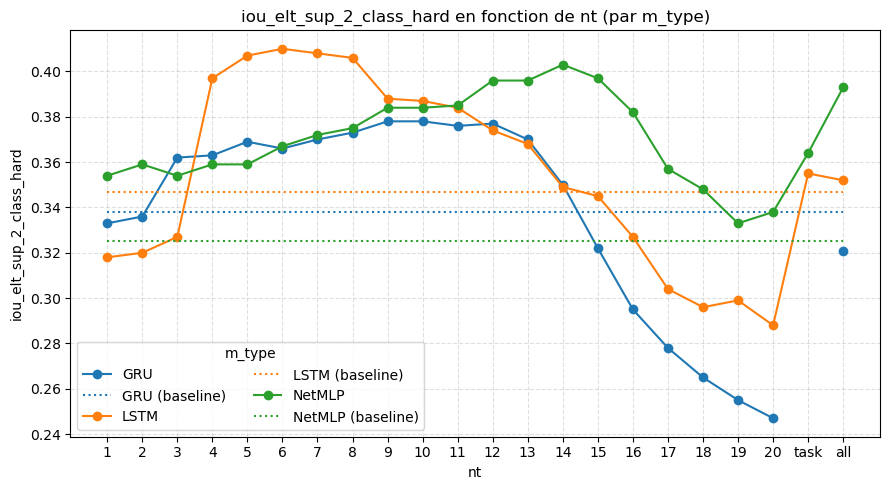

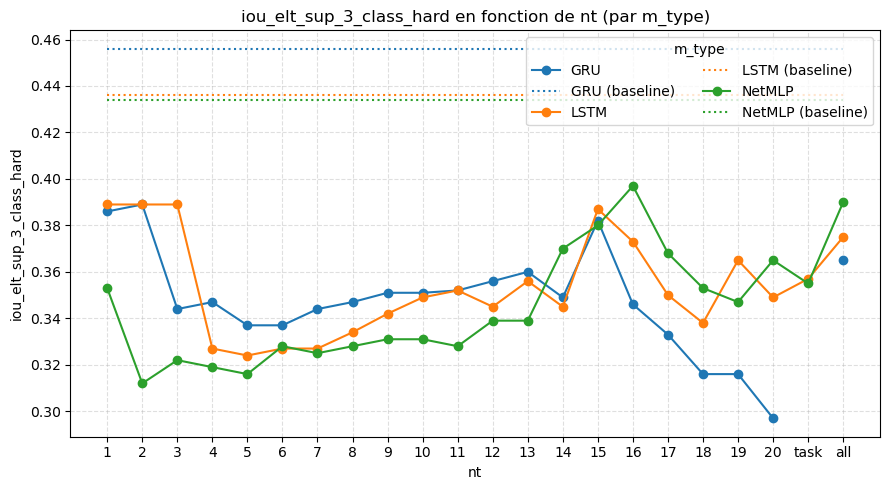

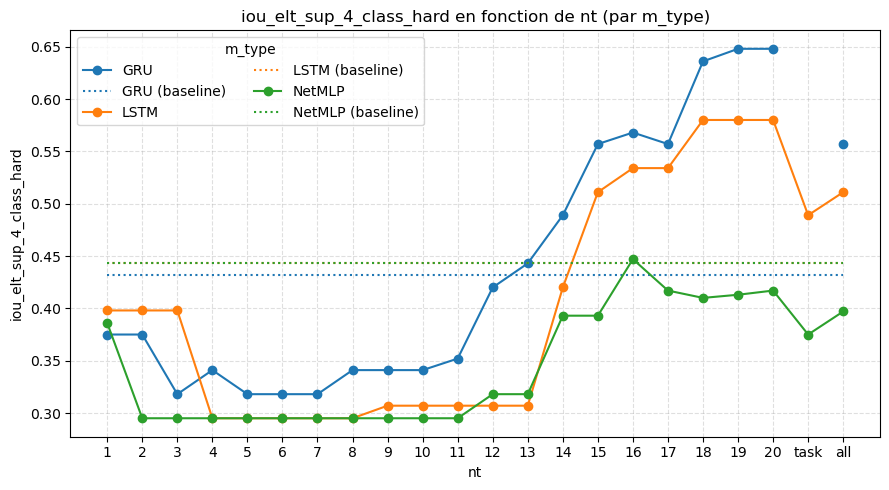

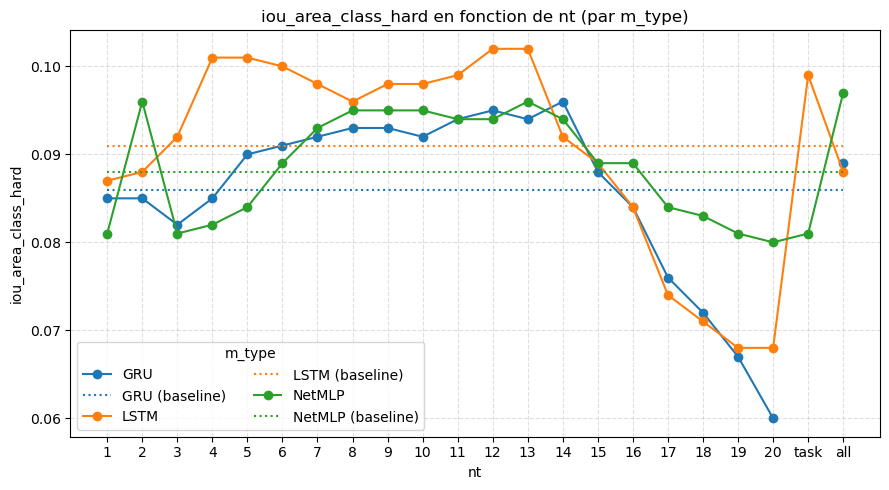

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_voting_model(df: pd.DataFrame, metric: str, title: str | None = None):
    """
    Trace la métrique en fonction de nt pour chaque m_type à partir de 'Model'
    au format: 'patch filter-{m_type}-{soft_or_hard}-{weight}-{nt}'.

    - nt ∈ {entier, 'all', 'task'}
    - On agrège (max) sur soft_or_hard et weight pour un même (m_type, nt)
    - Pour chaque m_type, on ajoute une ligne horizontale baseline
      correspondant aux lignes où Model == m_type (si présentes).
    """
    if "Model" not in df.columns:
        raise ValueError("La colonne 'Model' est absente du DataFrame.")
    if metric not in df.columns:
        raise ValueError(f"La colonne métrique '{metric}' est absente du DataFrame.")

    # Normaliser la colonne Model (strip guillemets/espaces accidentels)
    models = df["Model"].astype(str).str.strip().str.strip("'").str.strip('"')

    # Motif: "patch filter-{m_type}-{soft_or_hard}-{weight}-{nt}"
    pattern = (
    r"^(?:patch\s+)?filter-"
    r"(?P<m_type>[^-]+)-"
    r"(?P<soft_or_hard>soft|hard)-"
    r"(?P<weight>[^-]+)-"
    r"(?P<nt>(?:\d+|all|task))$"
    )
    parts = models.str.extract(pattern)

    mask = parts.notna().all(axis=1)
    if not mask.any():
        raise ValueError(
            "Aucun modèle ne correspond au motif "
            "'patch filter-{m_type}-{soft_or_hard}-{weight}-{nt}'."
        )

    work = pd.concat([df.loc[mask].reset_index(drop=True),
                      parts.loc[mask].reset_index(drop=True)], axis=1)

    # -- parsing/ordre de nt
    def _parse_nt(x: str):
        x = str(x)
        if x.isdigit():
            return ("int", int(x), x)      # kind, numeric order key, label
        x = x.lower()
        if x == "task":
            return ("task", np.inf - 1, "task")
        if x == "all":
            return ("all", np.inf, "all")
        return ("other", np.inf, x)

    parsed = work["nt"].map(_parse_nt)
    work["nt_kind"]  = parsed.map(lambda t: t[0])
    work["nt_num"]   = parsed.map(lambda t: t[1])
    work["nt_label"] = parsed.map(lambda t: t[2])

    # -- agrégation: max(metric) sur soft_or_hard et weight
    agg = (work
           .groupby(["m_type", "nt_kind", "nt_num", "nt_label"], as_index=False)[metric]
           .max())

    # -- tri
    kind_order = {"int": 0, "task": 1, "all": 2, "other": 3}
    agg["nt_kind_order"] = agg["nt_kind"].map(kind_order)
    agg = agg.sort_values(by=["m_type", "nt_kind_order", "nt_num"]).reset_index(drop=True)

    # Axe X commun
    all_x = (agg[["nt_kind_order", "nt_num", "nt_label"]]
             .drop_duplicates()
             .sort_values(by=["nt_kind_order", "nt_num"]))
    x_labels = all_x["nt_label"].tolist()
    x_pos = np.arange(len(x_labels))

    plt.figure(figsize=(9, 5))

    # Courbes + baseline par m_type
    for m_type, g in agg.groupby("m_type", sort=False):
        g2 = (g.set_index("nt_label")
                .reindex(x_labels)[metric])

        # Courbe principale
        line, = plt.plot(x_pos, g2.values, marker="o", label=str(m_type))
        color = line.get_color()

        # Baseline: lignes où Model == m_type (si présentes dans df original)
        base_mask = models == str(m_type)
        if base_mask.any():
            base_val = df.loc[base_mask, metric].max()
            plt.hlines(y=base_val,
                       xmin=x_pos.min() if len(x_pos) else 0,
                       xmax=x_pos.max() if len(x_pos) else 0,
                       linestyles=":",
                       linewidth=1.5,
                       colors=color,
                       label=f"{m_type} (baseline)")

    plt.xticks(x_pos, x_labels)
    plt.xlabel("nt")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="m_type", ncol=2)
    plt.title(title if title is not None else f"{metric} en fonction de nt (par m_type)")
    plt.tight_layout()
    plt.show()
    
plot_voting_model(df, 'f1')
plot_voting_model(df, 'iou_class_hard')
plot_voting_model(df, 'iou_elt_sup_1_class_hard')
plot_voting_model(df, 'iou_elt_sup_2_class_hard')
plot_voting_model(df, 'iou_elt_sup_3_class_hard')
plot_voting_model(df, 'iou_elt_sup_4_class_hard')
plot_voting_model(df, 'iou_area_class_hard')

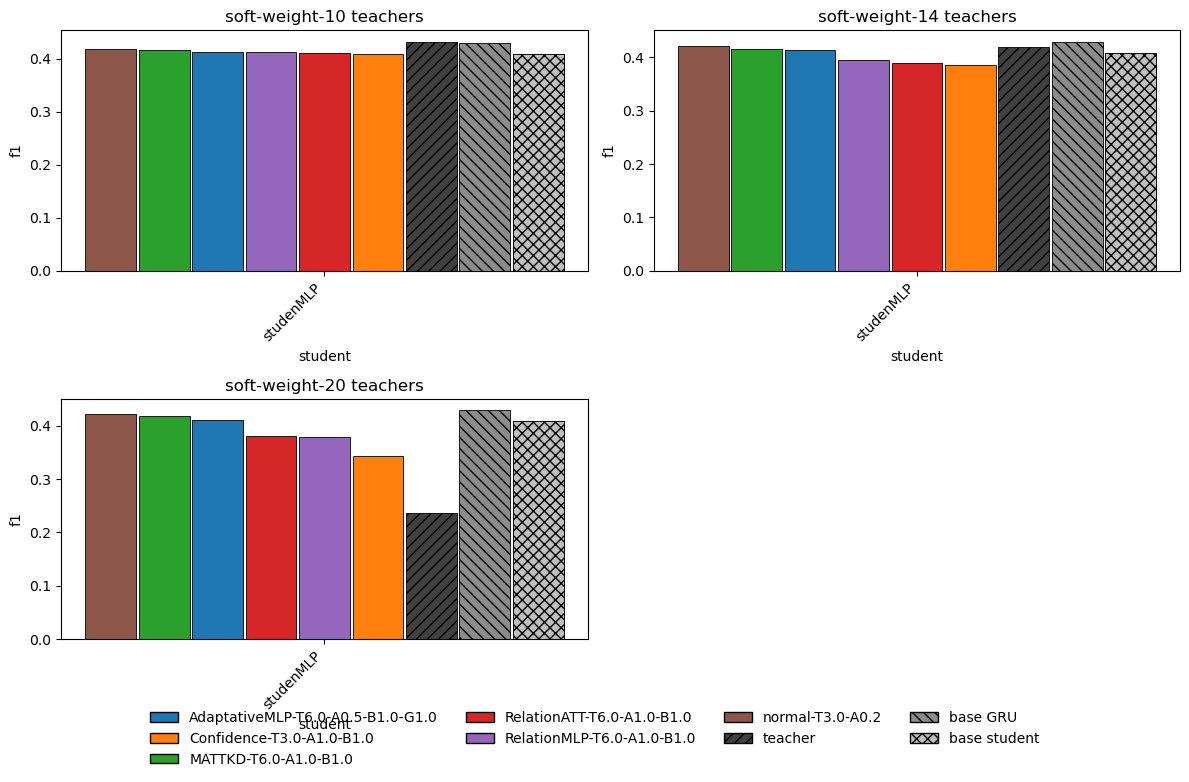

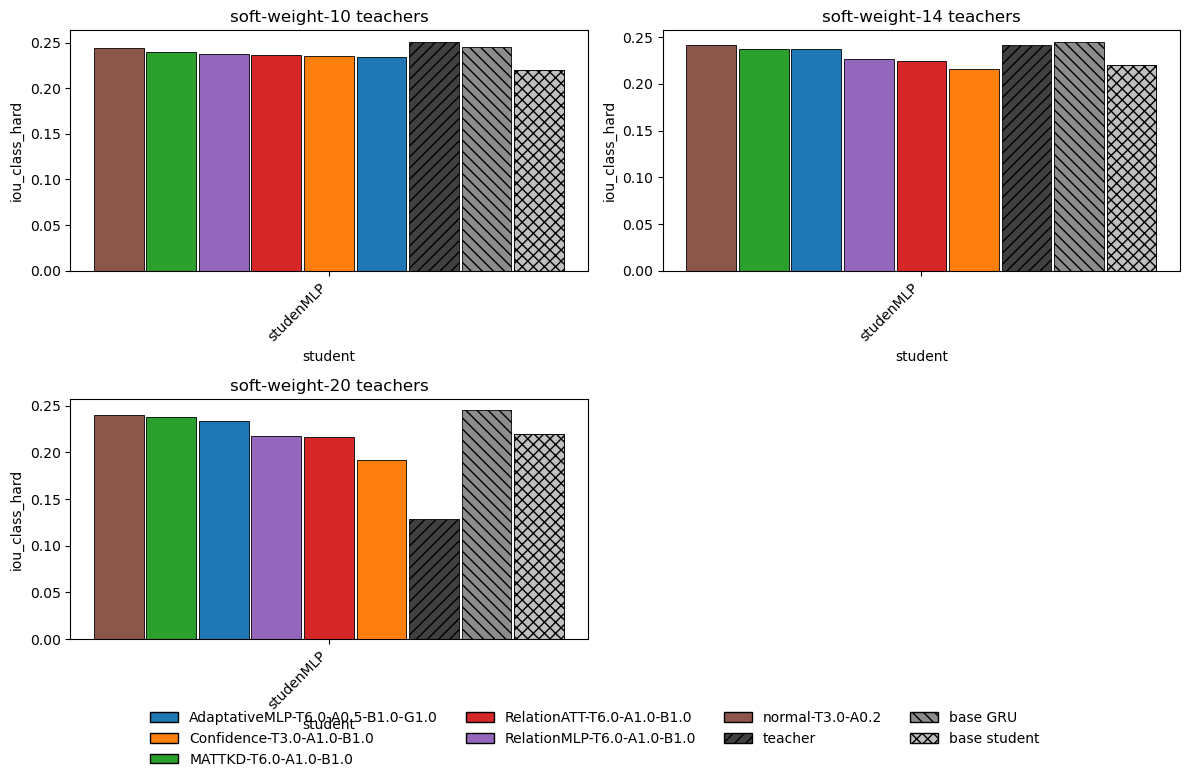

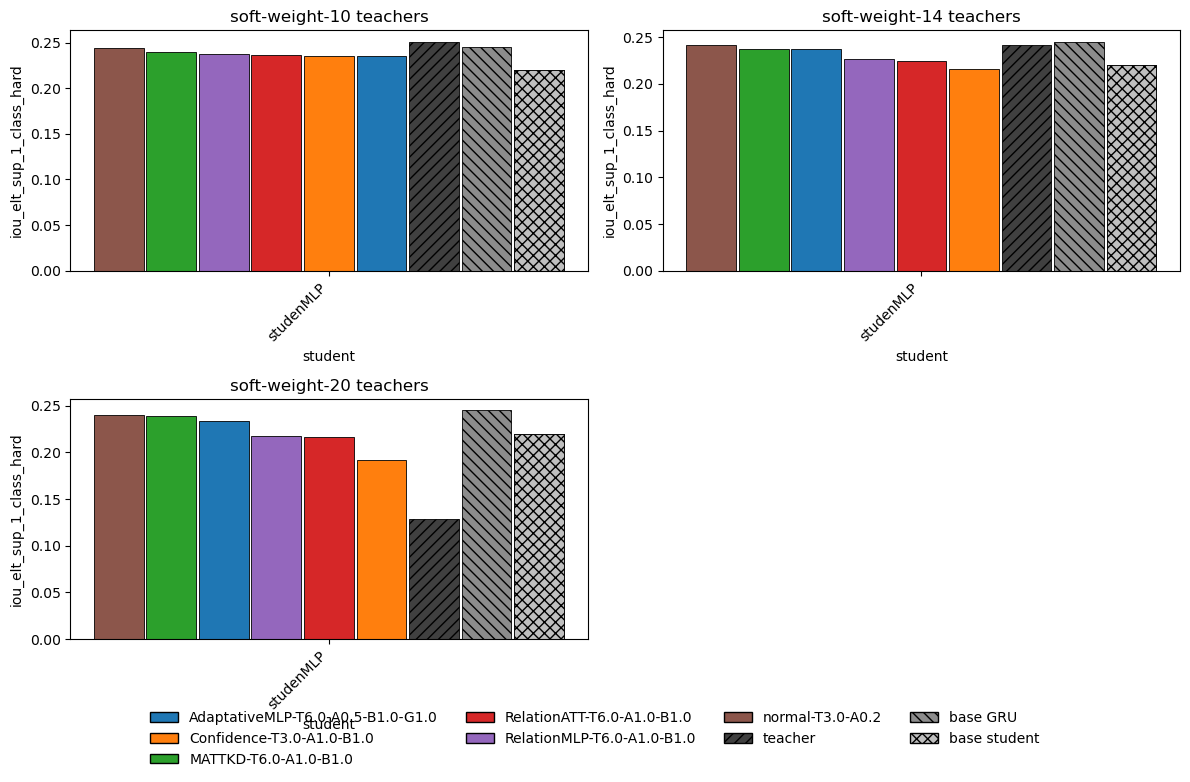

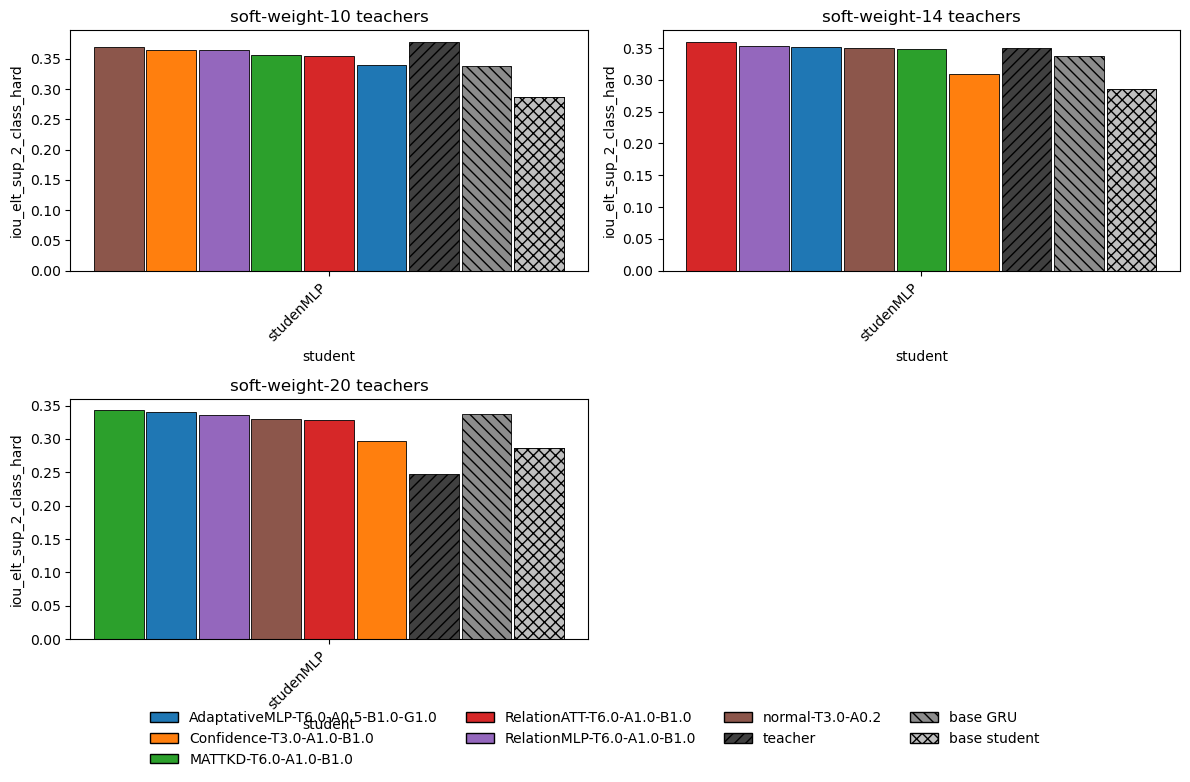

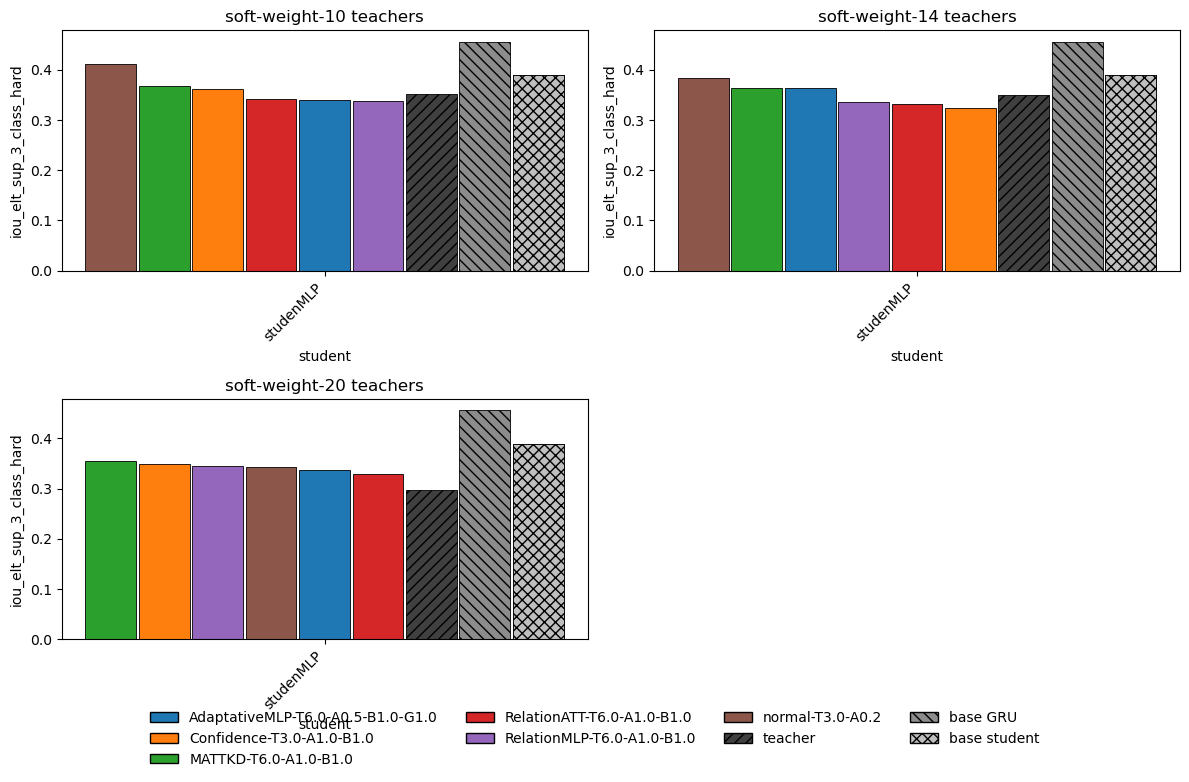

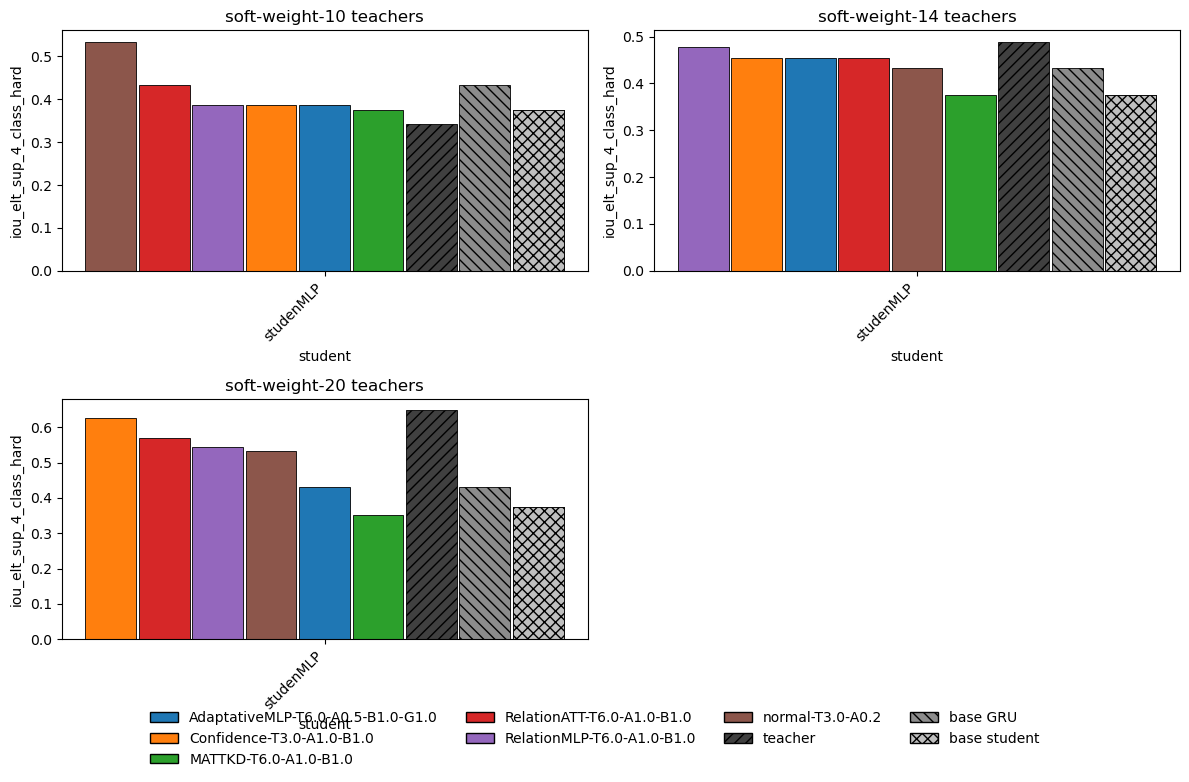

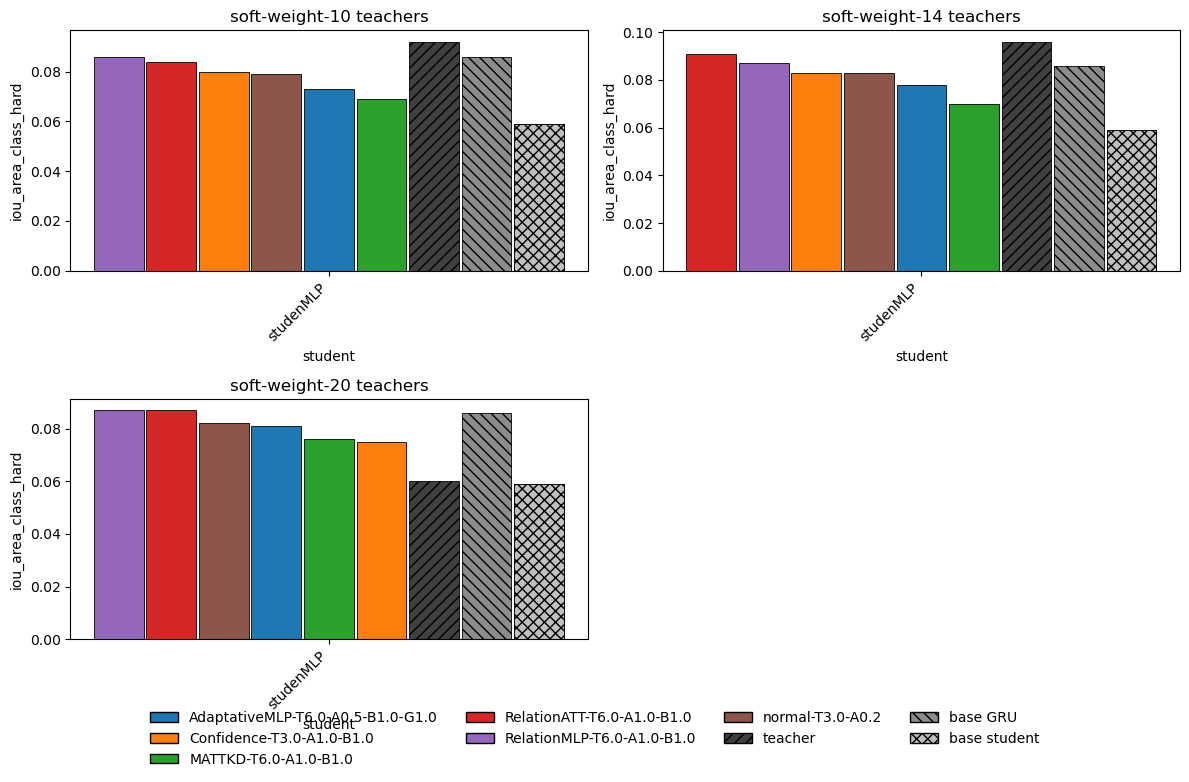

In [120]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def summarize_distillation(df: pd.DataFrame, metric: str, model_type: str):
    """
    df : DataFrame contenant au moins les colonnes ['Model', metric]
    metric : nom de la colonne de métrique (ex: 'accuracy')
    model_type : ex: 'bert', 'roberta', etc.

    Retourne un dict avec :
      - base_model : perf du modèle de base (= model_type)
      - teachers : df des teachers détectés
      - students_by_teacher : dict {n_teacher: subset_df} où subset_df contient :
            ['Model','student','config','n_teacher',metric,
             'teacher_<metric>', 'base_<metric>', 'base_student_<metric>']
      - base_student_map : dict {student_simple: perf_baseline_ou_None}
    """
    if "Model" not in df.columns:
        raise ValueError("La colonne 'Model' doit exister dans le DataFrame.")
    if metric not in df.columns:
        raise ValueError(f"La colonne métrique '{metric}' doit exister dans le DataFrame.")

    # --- 1) Extraire les modèles étudiants distillés ---
    # Pattern : {student}-{config}-filter-{model_type}-soft-weight-{n_teacher}_*
    pattern_student = re.compile(
        rf"^(?P<student>[^-]+)-(?P<config>.+?)-filter-{re.escape(model_type)}-soft-weight-(?P<n_teacher>\d+).*"
    )

    student_rows = []
    for _, row in df.iterrows():
        name = str(row["Model"])
        m = pattern_student.match(name)
        if m:
            student_rows.append({
                "Model": name,
                "student": m.group("student"),
                "config": m.group("config"),  # distillation_method + params...
                "n_teacher": int(m.group("n_teacher")),
                metric: row[metric],
            })

    students_df = pd.DataFrame(student_rows)

    # --- 2) Extraire les modèles teacher : filter-{model_type}-soft-weight-{n_teacher}_* ---
    pattern_teacher = re.compile(
        rf"^filter-{re.escape(model_type)}-soft-weight-(?P<n_teacher>\d+).*"
    )

    teacher_rows = []
    for _, row in df.iterrows():
        name = str(row["Model"])
        m = pattern_teacher.match(name)
        if m:
            teacher_rows.append({
                "Model": name,
                "n_teacher": int(m.group("n_teacher")),
                metric: row[metric],
            })

    teachers_df = pd.DataFrame(teacher_rows)

    # --- 3) Perf du modèle de base {model_type} ---
    base_model_perf = None
    base_mask = df["Model"] == model_type
    if base_mask.any():
        vals = pd.to_numeric(df.loc[base_mask, metric], errors="coerce").dropna()
        base_model_perf = float(vals.mean()) if not vals.empty else None

    # --- 3bis) Perf du modèle "base student" (ex: studenMLP) ---
    # On suppose que le baseline porte exactement le nom du student simple (sans suffixe).
    base_student_perf_map = {}
    if not students_df.empty:
        unique_students = sorted(students_df["student"].dropna().unique())
        for s in unique_students:
            mask = (df["Model"] == s)
            if mask.any():
                vals = pd.to_numeric(df.loc[mask, metric], errors="coerce").dropna()
                base_student_perf_map[s] = float(vals.mean()) if not vals.empty else None
            else:
                base_student_perf_map[s] = None

    # --- 4) Vue par n_teacher ---
    students_by_teacher = {}
    if not students_df.empty:
        for n in sorted(students_df["n_teacher"].unique()):
            subset = students_df[students_df["n_teacher"] == n].copy()
            subset = subset.sort_values(by=metric, ascending=False)
            students_by_teacher[n] = subset

    # --- 5) Ajouter perf des teachers/base/base-student dans chaque subset ---
    if not teachers_df.empty:
        teacher_metric_map = teachers_df.set_index("n_teacher")[metric].to_dict()
    else:
        teacher_metric_map = {}

    for n, sub in students_by_teacher.items():
        teacher_perf = teacher_metric_map.get(n, None)
        sub = sub.copy()

        sub["teacher_" + metric] = teacher_perf

        if base_model_perf is not None:
            sub["base_" + metric] = base_model_perf

        # baseline du student simple (varie par ligne)
        if base_student_perf_map:
            sub["base_student_" + metric] = sub["student"].map(base_student_perf_map)
        else:
            sub["base_student_" + metric] = np.nan

        students_by_teacher[n] = sub

    result = {
        "model_type": model_type,
        "metric": metric,
        "base_model": base_model_perf,
        "base_student_map": base_student_perf_map,
        "teachers": teachers_df,
        "students_by_teacher": students_by_teacher,
    }

    return result

# ------------------------------------------------------------
# Couleurs stables PAR STUDENT, à partir de summarize_distillation()
# ------------------------------------------------------------
def make_student_color_map_from_summary(summary: dict) -> dict:
    # Collecte tous les students (tous n_teacher)
    students = set()
    for _, sub in summary["students_by_teacher"].items():
        if "student" in sub.columns:
            students.update(sub["student"].dropna().unique().tolist())

    students = sorted(students)
    cmap = plt.get_cmap("tab20") if len(students) > 10 else plt.get_cmap("tab10")
    return {s: cmap(i % cmap.N) for i, s in enumerate(students)}


# ------------------------------------------------------------
# Hachures stables PAR CONFIG (toujours depuis le summary)
# ------------------------------------------------------------
def make_series_style_maps_from_summary(summary: dict):
    configs = set()
    for _, sub in summary["students_by_teacher"].items():
        if "config" in sub.columns:
            configs.update(sub["config"].dropna().unique().tolist())
    configs = sorted(configs)

    hatch_cycle = ["", "///", "\\\\\\", "xxx", "++", "...", "oo", "**", "--", "||"]
    hatch_map = {cfg: hatch_cycle[i % len(hatch_cycle)] for i, cfg in enumerate(configs)}

    hatch_map["teacher"] = "///"
    hatch_map["base_model"] = "\\\\\\"
    hatch_map["base_student"] = "xxx"
    return configs, hatch_map

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def make_config_color_map_from_summary(summary: dict) -> dict:
    configs = set()
    for _, sub in summary["students_by_teacher"].items():
        if "config" in sub.columns:
            configs.update(sub["config"].dropna().unique().tolist())
    configs = sorted(configs)

    cmap = plt.get_cmap("tab20") if len(configs) > 10 else plt.get_cmap("tab10")
    return {cfg: cmap(i % cmap.N) for i, cfg in enumerate(configs)}


def plot_distillation_results(
    df,
    metric: str,
    model_type: str,
    config_color_map: dict | None = None,
):
    summary = summarize_distillation(df, metric, model_type)

    students_by_teacher = summary["students_by_teacher"]
    base_model_perf = summary["base_model"]
    base_student_map = summary.get("base_student_map", {})

    if not students_by_teacher:
        raise ValueError("Aucun modèle distillé trouvé pour ce model_type.")

    if config_color_map is None:
        config_color_map = make_config_color_map_from_summary(summary)

    # configs globales (pour légende)
    configs = []
    for _, sub in students_by_teacher.items():
        if "config" in sub.columns:
            configs += sub["config"].dropna().unique().tolist()
    configs = sorted(set(configs))

    # Couleurs fixes pour les baselines / teacher
    special_colors = {
        "teacher": "0.25",
        "base_model": "0.55",
        "base_student": "0.75",
    }
    special_hatch = {
        "teacher": "///",
        "base_model": "\\\\\\",
        "base_student": "xxx",
    }

    n_teachers = len(students_by_teacher)
    ncols = 2
    nrows = int(np.ceil(n_teachers / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)
    axes = axes.flatten()

    legend_handles = None

    for ax, (n_teacher, sub) in zip(axes, students_by_teacher.items()):
        students = list(sub["student"].unique())
        x = np.arange(len(students))

        teacher_col = "teacher_" + metric
        has_teacher = teacher_col in sub.columns and not sub[teacher_col].isna().all()
        teacher_val = float(sub[teacher_col].iloc[0]) if has_teacher else None

        has_base = base_model_perf is not None

        base_student_col = "base_student_" + metric
        if base_student_col in sub.columns:
            base_student_vals = pd.to_numeric(sub[base_student_col], errors="coerce").to_numpy(dtype=float)
        else:
            base_student_vals = np.array(
                [np.nan if base_student_map.get(s) is None else float(base_student_map[s]) for s in students],
                dtype=float
            )
        has_base_student = np.isfinite(base_student_vals).any()

        # Séries visibles dans ce subplot
        configs_here = list(sub["config"].dropna().unique()) if "config" in sub.columns else []
        series_labels = configs_here + (
            (["teacher"] if has_teacher else [])
            + (["base_model"] if has_base else [])
            + (["base_student"] if has_base_student else [])
        )

        n_bars = len(series_labels)
        group_width = 0.85
        bar_width = group_width / max(n_bars, 1)

        def offset(j: int) -> float:
            return (j - (n_bars - 1) / 2) * bar_width

        # --- configs distillées : couleur = config ---
        for j, cfg in enumerate(configs_here):
            group = sub[sub["config"] == cfg]
            y_map = dict(zip(group["student"], group[metric]))
            ys = np.array([y_map.get(s, np.nan) for s in students], dtype=float)

            ax.bar(
                x + offset(j),
                ys,
                width=bar_width * 0.95,
                color=config_color_map.get(cfg, None),
                edgecolor="black",
                linewidth=0.6,
                label=str(cfg),
            )

        idx = len(configs_here)

        # --- teacher ---
        if has_teacher:
            ax.bar(
                x + offset(idx),
                np.full(len(students), teacher_val, dtype=float),
                width=bar_width * 0.95,
                color=special_colors["teacher"],
                hatch=special_hatch["teacher"],
                edgecolor="black",
                linewidth=0.6,
                label=f"teacher (n={n_teacher})",
            )
            idx += 1

        # --- base model ---
        if has_base:
            ax.bar(
                x + offset(idx),
                np.full(len(students), float(base_model_perf), dtype=float),
                width=bar_width * 0.95,
                color=special_colors["base_model"],
                hatch=special_hatch["base_model"],
                edgecolor="black",
                linewidth=0.6,
                label=f"base {model_type}",
            )
            idx += 1

        # --- base student ---
        if has_base_student:
            ax.bar(
                x + offset(idx),
                base_student_vals,
                width=bar_width * 0.95,
                color=special_colors["base_student"],
                hatch=special_hatch["base_student"],
                edgecolor="black",
                linewidth=0.6,
                label="base student",
            )

        ax.set_title(f"soft-weight-{n_teacher} teachers")
        ax.set_xlabel("student")
        ax.set_ylabel(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(students, rotation=45, ha="right")

        # Légende commune (construite une seule fois)
        if legend_handles is None:
            handles = []
            # configs = couleurs
            for cfg in configs:
                handles.append(Patch(facecolor=config_color_map.get(cfg, "white"),
                                     edgecolor="black",
                                     label=str(cfg)))
            # spéciaux
            handles += [
                Patch(facecolor=special_colors["teacher"], edgecolor="black", hatch=special_hatch["teacher"], label="teacher"),
                Patch(facecolor=special_colors["base_model"], edgecolor="black", hatch=special_hatch["base_model"], label=f"base {model_type}"),
                Patch(facecolor=special_colors["base_student"], edgecolor="black", hatch=special_hatch["base_student"], label="base student"),
            ]
            legend_handles = handles

        # pas de légende locale
        if ax.get_legend() is not None:
            ax.legend_.remove()

    # Désactive les axes vides
    for k in range(n_teachers, len(axes)):
        axes[k].axis("off")

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc="lower center",
            ncol=min(len(legend_handles), 4),
            frameon=False,
            bbox_to_anchor=(0.5, 0.02),
        )

    fig.tight_layout(rect=(0, 0.06, 1, 1))
    plt.show()


def plot_distillation_metrics(df, metrics: list[str], model_type: str):
    # palette stable UNE FOIS
    summary0 = summarize_distillation(df, metrics[0], model_type)
    config_color_map = make_config_color_map_from_summary(summary0)

    for metric in metrics:
        plot_distillation_results(df, metric, model_type, config_color_map=config_color_map)



# --- Utilisation ---
metrics = [
    "f1",
    "iou_class_hard",
    "iou_elt_sup_1_class_hard",
    "iou_elt_sup_2_class_hard",
    "iou_elt_sup_3_class_hard",
    "iou_elt_sup_4_class_hard",
    "iou_area_class_hard",
]
plot_distillation_metrics(df, metrics, "GRU")

In [121]:
summarize_distillation(df, 'f1', 'GRU').keys()

dict_keys(['model_type', 'metric', 'base_model', 'base_student_map', 'teachers', 'students_by_teacher'])

In [122]:
df.Model.unique()

array(['studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'filter-GRU-soft-weight-1', 'filter-GRU-soft-weight-2',
       'filter-GRU-soft-weight-3', 'filter-GRU-soft-weight-4',
       'filter-GRU-soft-weight-5', 'filter-GRU-soft-weight-6',
       'filter-GRU-soft-weight-7', 'filter-GRU-soft-weight-8',
       'filter-GRU-soft-weight-9', 'filter-GRU-soft-weight-10',
       'filter-GRU-soft-weight-11', 'filter-GRU-soft-weight-12',
       'filter-GRU-soft-weight-13', 'filter-GRU-soft-weight-14',
       'filter-GRU-soft-weight-15', 'filter-GRU-soft-weight-16',
       'filter-GRU-soft-weight-17', 'filter-GRU-soft-w

In [123]:
df = df[df['Loss_function'] == 'wkloss']

In [124]:
import pandas as pd
import numpy as np

def to_latex(df: pd.DataFrame, metrics: list[list[str]], loss: str, targets: list[str]) -> str:
    """
    Génère un tableau LaTeX :
    - une ligne par modèle
    - chaque métrique est affichée comme "mean ± std" avec 2 chiffres après la virgule
    - NaN si la métrique pour un modèle/target n'existe pas
    - filtrage par Loss_function
    """

    # Filtrer par loss
    df = df[df["Loss_function"] == loss]

    if df.empty:
        raise ValueError(f"Aucune ligne trouvée avec Loss_function == '{loss}'")

    # Liste des modèles uniques
    models = df["Model"].unique()

    # Colonnes de métriques
    ordered_metrics = [m for group in metrics for m in group]

    col_format = "l" + "c" * len(ordered_metrics)

    # En-tête
    target_header = ["Model"]
    for target, group in zip(targets, metrics):
        target_header.extend([target] * len(group))
    target_header = " & ".join(target_header) + " \\\\"

    metric_header = [""] + ordered_metrics
    metric_header = " & ".join(metric_header) + " \\\\"

    rows = []

    for model in models:
        values = [model]

        for target_group, target in zip(metrics, targets):
            for m in target_group:
                # colonne std correspondante
                std_col = "std_" + (m[5:] if m.startswith("mean_") else m)

                # Filtrer sur modèle et target exact
                matching_rows = df[(df["Model"] == model) & (df["Target"] == target)]

                if not matching_rows.empty:
                    mean_val = matching_rows.iloc[0].get(m, np.nan)
                    std_val = matching_rows.iloc[0].get(std_col, np.nan)
                    if pd.isna(mean_val) or pd.isna(std_val):
                        val = "NaN"
                    else:
                        val = f"{mean_val:.2f} ± {std_val:.2f}"  # deux chiffres après la virgule
                else:
                    val = "NaN"

                values.append(val)
                 
        rows.append(" & ".join(values) + " \\\\")

    # Construction du tableau LaTeX
    latex = []
    latex.append("\\begin{tabular}{" + col_format + "}")
    latex.append("\\hline")
    latex.append(target_header)
    latex.append(metric_header)
    latex.append("\\hline")
    latex.extend(rows)
    latex.append("\\hline")
    latex.append("\\end{tabular}")
    
    return "\n".join(latex)

print(to_latex(df, metrics=[['mean_f1_test', 'mean_prec_test', 'mean_recall_test', 'mean_iou_test', 'mean_auoc_test'], \
                            ['mean_iou_test', 'mean_auoc_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept', 'burnedareaRoot-kmeans-5-Class-Dept']))

\begin{tabular}{lccccccc}
\hline
Model & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & burnedareaRoot-kmeans-5-Class-Dept & burnedareaRoot-kmeans-5-Class-Dept \\
 & mean_f1_test & mean_prec_test & mean_recall_test & mean_iou_test & mean_auoc_test & mean_iou_test & mean_auoc_test \\
\hline
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-w

In [125]:
print(to_latex(df, metrics=[['mean_f1_elt_sup_3.0_test', 'mean_prec_elt_sup_3.0_test', 'mean_rec_elt_sup_3.0_test', 'mean_iou_elt_sup_3.0_test', 'mean_auoc_elt_sup_3.0_test'], \
                            ['mean_iou_elt_sup_3.0_test', 'mean_auoc_elt_sup_3.0_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept', 'burnedareaRoot-kmeans-5-Class-Dept']))

\begin{tabular}{lccccccc}
\hline
Model & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & burnedareaRoot-kmeans-5-Class-Dept & burnedareaRoot-kmeans-5-Class-Dept \\
 & mean_f1_elt_sup_3.0_test & mean_prec_elt_sup_3.0_test & mean_rec_elt_sup_3.0_test & mean_iou_elt_sup_3.0_test & mean_auoc_elt_sup_3.0_test & mean_iou_elt_sup_3.0_test & mean_auoc_elt_sup_3.0_test \\
\hline
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10 & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14 & NaN & NaN & NaN 

In [126]:
print(to_latex(df, metrics=[['mean_normalized_f1_test', 'mean_normalized_prec_test', 'mean_normalized_rec_test', 'mean_normalized_iou_test'], \
                            ['mean_normalized_iou_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept', 'burnedareaRoot-kmeans-5-Class-Dept']))

\begin{tabular}{lccccc}
\hline
Model & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & nbsinister-kmeans-5-Class-Dept & burnedareaRoot-kmeans-5-Class-Dept \\
 & mean_normalized_f1_test & mean_normalized_prec_test & mean_normalized_rec_test & mean_normalized_iou_test & mean_normalized_iou_test \\
\hline
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10 & NaN & NaN & NaN & NaN & NaN \\
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14 & NaN & NaN & NaN & NaN & NaN \\
studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20 & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10 & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14 & NaN & NaN & NaN & NaN & NaN \\
studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-20 & NaN & NaN & NaN & NaN & NaN \\
filter-GRU-soft-weight-1 & NaN & NaN & NaN & NaN & NaN \\
filter-GRU-sof

In [127]:
df[(df['Task_type'] == 'binary') & (df['Loss_function'] == 'softmax')]['rec_area_class_hard']

Series([], Name: rec_area_class_hard, dtype: float64)

In [128]:
[[0]] + [i for i in range(4)]

[[0], 0, 1, 2, 3]

In [129]:
from typing import Optional, Dict, Sequence, Tuple, Union
import os
import fnmatch
import pickle
import pandas as pd
import paramiko

def load_prediction(
    ip: str,
    user: str,
    password: str,
    remote_dir: str,
    models: Sequence[str],           # <- liste de modèles
    horizon: Union[int, str],
    return_concat: bool = True      # <- option pour renvoyer aussi un DF concaténé
) -> Union[Dict[str, Optional[pd.DataFrame]],
           Tuple[Dict[str, Optional[pd.DataFrame]], Optional[pd.DataFrame]]]:

    """
    Charge pour chaque modèle de `models` la prédiction la plus récente
    (pickle) depuis le répertoire SFTP:
        {remote_dir}/{model}/H{horizon}/{model}_full_all_departement_0_None_node_z-score_Catboost_all_pred.pkl

    Renvoie:
      - Par défaut: dict {model: DataFrame ou None}
      - Si return_concat=True: (dict, df_concat ou None)
        où df_concat = concaténation verticale de tous les DF non-nuls,
        avec une colonne additionnelle 'model' pour identifier la source.
    """

    # Sécurité: accepte un seul modèle passé par erreur sous forme de str
    if isinstance(models, str):
        models = [models]

    transport = None
    sftp = None
    results: Dict[str, Optional[pd.DataFrame]] = {}

    try:
        # Connexion SFTP unique réutilisée pour tous les modèles
        transport = paramiko.Transport((ip, 22))
        transport.connect(username=user, password=password)
        sftp = paramiko.SFTPClient.from_transport(transport)

        for model in models:
            try:
                model_dir = os.path.join(remote_dir, model, f"H{horizon}")
                # Liste des fichiers présents
                files = sftp.listdir(model_dir)

                # Motif des fichiers attendus
                pattern = f"{model}_full_all_departement_0_None_node_z-score_Catboost_all_pred.pkl"
                matched_files = fnmatch.filter(files, pattern)

                if not matched_files:
                    print(f"[{model}] Aucun fichier ne matche {pattern} dans {model_dir}")
                    results[model] = None
                    continue

                # Tri par date de modif décroissante, on prend le plus récent
                matched_files.sort(
                    key=lambda x: sftp.stat(os.path.join(model_dir, x)).st_mtime,
                    reverse=True
                )
                latest_file = matched_files[0]
                remote_file_path = os.path.join(model_dir, latest_file)

                # Lecture du pickle
                with sftp.open(remote_file_path, "rb") as f:
                    obj = pickle.load(f)

                if isinstance(obj, pd.DataFrame):
                    df = obj
                else:
                    try:
                        df = pd.DataFrame(obj)
                    except Exception:
                        print(f"[{model}] Le pickle n'est pas un DataFrame et n'est pas convertible.")
                        df = None

                results[model] = df

            except FileNotFoundError:
                print(f"[{model}] Répertoire introuvable: {os.path.join(remote_dir, model, f'H{horizon}')} ")
                results[model] = None
            except Exception as e:
                print(f"[{model}] Erreur: {e}")
                results[model] = None

    except Exception as e:
        print(f"Erreur de connexion SFTP: {e}")
        # Si la connexion échoue, retourner un dict None pour tous les modèles
        for m in models:
            results.setdefault(m, None)
    finally:
        # Fermeture propre
        try:
            if sftp is not None:
                sftp.close()
        finally:
            if transport is not None:
                transport.close()

    if not return_concat:
        return results

    # Concatène les DF valides et ajoute la colonne 'model'
    dfs = []
    for m, df in results.items():
        if isinstance(df, pd.DataFrame):
            tmp = df.copy()
            if 'model' not in tmp.columns:
                tmp.insert(0, 'model', m)
            else:
                tmp['model'] = m  # écrase au cas où
            dfs.append(tmp)

    df_concat = pd.concat(dfs, ignore_index=True) if dfs else None
    return df_concat

In [130]:
df.Model.unique()

array(['studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'filter-GRU-soft-weight-1', 'filter-GRU-soft-weight-2',
       'filter-GRU-soft-weight-3', 'filter-GRU-soft-weight-4',
       'filter-GRU-soft-weight-5', 'filter-GRU-soft-weight-6',
       'filter-GRU-soft-weight-7', 'filter-GRU-soft-weight-8',
       'filter-GRU-soft-weight-9', 'filter-GRU-soft-weight-10',
       'filter-GRU-soft-weight-11', 'filter-GRU-soft-weight-12',
       'filter-GRU-soft-weight-13', 'filter-GRU-soft-weight-14',
       'filter-GRU-soft-weight-15', 'filter-GRU-soft-weight-16',
       'filter-GRU-soft-weight-17', 'filter-GRU-soft-w

In [131]:
import datetime as dt

def find_dates_between(start, end):
    start_date = dt.datetime.strptime(start, '%Y-%m-%d').date()
    end_date = dt.datetime.strptime(end, '%Y-%m-%d').date()

    delta = dt.timedelta(days=1)
    date = start_date
    res = []
    while date < end_date:
            res.append(date.strftime("%Y-%m-%d"))
            date += delta
    return res

allDates = find_dates_between('2017-06-12', '2025-01-01')

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from typing import Dict, Tuple, Optional, List

def mean_confusion_by_model(
    df: pd.DataFrame,
    target_col: str,
    prediction_col: str,
    model_col: str = "Model",
    labels: Optional[List[str]] = None,  # libellés d'affichage
    classes: Optional[List[int]] = None, # ordre des classes pour la matrice (ex: [0,1,2,3,4])
    weighted: bool = False,              # moyenne pondérée par la taille du groupe
    plot: bool = True,
    figsize: Tuple[int, int] = (7, 6),
    title: str = "Mean normalized confusion matrix by model",
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Retourne:
      - mean_cm: matrice de confusion moyenne (normalisée par les valeurs de target)
      - per_model_cms: dict {nom_model: matrice_normalisée}
    """
    # Nettoyage minimal
    data = df[[target_col, prediction_col, model_col]].dropna()

    # Détermine l'ordre des classes (stabilité des dimensions)
    if classes is None:
        # union des valeurs présentes dans target et preds
        uniq = pd.Index(np.union1d(data[target_col].unique(), data[prediction_col].unique()))
        # on essaie d'ordonner naturellement si ce sont des entiers
        try:
            classes = sorted(uniq.astype(int).tolist())
        except Exception:
            classes = uniq.tolist()

    n_classes = len(classes)

    # Libellés par défaut (5 classes)
    if labels is None:
        labels = [
            "No fire",
            "Small number of fire",
            "Medium number of fire",
            "High number of fire",
            "Extreme number of fire",
        ]
    if len(labels) != n_classes:
        raise ValueError(
            f"Le nombre de labels ({len(labels)}) ne correspond pas au nombre de classes ({n_classes})."
        )

    # Calcul par modèle
    per_model_cms: Dict[str, np.ndarray] = {}
    weights = []
    for model_name, g in data.groupby(model_col):
        y_true = g[target_col].to_numpy()
        y_pred = g[prediction_col].to_numpy()

        # matrice normalisée par les valeurs vraies (lignes)
        cm = confusion_matrix(
            y_true, y_pred, labels=classes, normalize="true"
        ).astype(float)
        per_model_cms[model_name] = cm
        weights.append(len(g))

    if not per_model_cms:
        raise ValueError("Aucun groupe modèle trouvé après nettoyage des données.")

    # Moyenne (pondérée ou non)
    cms_stack = np.stack(list(per_model_cms.values()), axis=0)  # (M, C, C)
    if weighted:
        w = np.array(weights, dtype=float)
        w = w / w.sum()
        mean_cm = np.tensordot(w, cms_stack, axes=(0, 0))
    else:
        mean_cm = cms_stack.mean(axis=0)

    # Tracé optionnel
    if plot:
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(mean_cm, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_xticks(np.arange(n_classes))
        ax.set_yticks(np.arange(n_classes))
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_yticklabels(labels)

        # Valeurs dans les cases
        thresh = mean_cm.max() / 2.0
        for i in range(n_classes):
            for j in range(n_classes):
                val = mean_cm[i, j]
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()

    return mean_cm, per_model_cms

In [133]:
import numpy as np

def ordinal_ece(probs, y_true, n_bins=10):
    """
    probs: (N, K) probas prédites pour chaque classe ordinale
    y_true: (N,) labels réels {0..K-1}
    """
    N, K = probs.shape
    ece = 0.0
    bin_edges = np.linspace(0, 1, n_bins+1)

    # Convertir probas en CDF ordinale
    cdf_pred = np.cumsum(probs, axis=1)  # shape (N, K)

    # On ne considère pas la classe max (CDF==1)
    for k in range(K-1):
        conf_k = cdf_pred[:, k]          # P(Y <= k)
        true_k = (y_true <= k).astype(float)

        for b in range(n_bins):
            # indices du bin
            in_bin = (conf_k >= bin_edges[b]) & (conf_k < bin_edges[b+1])
            if not np.any(in_bin):
                continue
            
            freq = np.mean(true_k[in_bin])
            conf = np.mean(conf_k[in_bin])
            ece += (np.sum(in_bin) / N) * abs(freq - conf)
            
    return ece

In [134]:
import numpy as np
import matplotlib.pyplot as plt

def plot_calibration_with_background(
    probs,
    y_true,
    n_bins=10,
    ks=None,
    figsize=(25, 5),
    title="Calibration",
    average="micro",
    eps=1e-12,
    show_bin_counts=True,
    classwise=True,     # nominal one-vs-rest (existant)
    tailwise=False,     # <<< NOUVEAU : calibration P(Y >= c | Y>0) par seuil c
):
    """
    Modes disponibles :
      - classwise=True  (nominal one-vs-rest, un panneau par classe P(Y=c))
      - tailwise=True   (nouveau) calibration de queue conditionnelle P(Y >= c | Y>0)
      - sinon : mode ordinal conditionnel (CDF) + binaire P(Y>0) comme avant.

    tailwise:
      * On restreint aux échantillons positifs (Y>0 et p_pos>eps)
      * Pour chaque c in {1..K-1}, on trace:
            conf_c = P_hat(Y>=c | Y>0) = 1 - CDF_pos(c-1)
            true_c = 1[(Y>=c) | Y>0]
        et on calcule une ECE par c.
    """
    probs = np.asarray(probs, float)
    y_true = np.asarray(y_true, int)
    N, K = probs.shape

    if classwise and tailwise:
        raise ValueError("Use either classwise=True or tailwise=True, not both.")

    bins = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    # ----------------------- MODE NOMINAL (par classe) ----------------------- #
    if classwise and not tailwise:
        n_panels = K
        fig, axes = plt.subplots(1, n_panels, figsize=(max(10, 3 * n_panels), figsize[1]))
        if n_panels == 1:
            axes = [axes]

        eces = []
        stats = {"ECE_event": None, "mode": "classwise"}

        for c in range(K):
            p = probs[:, c]
            t = (y_true == c).astype(float)

            conf_means, freq_means, counts = [], [], []
            ece_c = 0.0; used_bins = 0

            for b in range(n_bins):
                lo, hi = bins[b], bins[b + 1]
                mask = (p >= lo) & (p < hi if b < n_bins - 1 else p <= hi)
                nb = int(mask.sum()); counts.append(nb)
                if nb == 0:
                    conf_means += [np.nan]; freq_means += [np.nan]; continue
                cm = p[mask].mean(); fm = t[mask].mean()
                conf_means.append(cm); freq_means.append(fm)
                if average == "micro":
                    ece_c += (nb / N) * abs(fm - cm)
                else:
                    ece_c += abs(fm - cm); used_bins += 1
            if average == "macro" and used_bins > 0:
                ece_c /= used_bins

            eces.append(ece_c)
            ax = axes[c]
            conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
            valid = np.isfinite(conf_means) & np.isfinite(freq_means)
            ax.plot([0,1],[0,1],"k:",lw=1)
            ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_c:.3f}")
            ax.set_title(f"Class {c}")
            ax.set_xlabel(f"P(Y = {c})"); ax.set_ylabel(f"Observed freq. (Y = {c})")
            ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
            if show_bin_counts:
                ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])
            stats[f"ECE_class_{c}"] = float(ece_c)
            
        eces = np.array(eces, float)
        stats["ECE_macro_over_classes"] = float(np.nanmean(eces))
        stats["ECE_micro_over_classes"] = float(np.nansum(eces)) if average == "micro" else None
        fig.tight_layout()
        return fig, axes, stats

    # ----------------------- MODE TAILWISE (NOUVEAU) ------------------------ #
    if tailwise:
        # Positifs : normalisation conditionnelle
        p_pos = 1 - probs[:, 0]
        mask_pos = p_pos > eps
        if not np.any(mask_pos):
            raise ValueError("No samples with positive-event probability above eps.")
        cond_probs = probs[mask_pos, 1:] / p_pos[mask_pos, None]
        y_pos = y_true[mask_pos]
        mask_truepos = y_pos > 0
        cond_probs = cond_probs
        y_pos = y_pos
        if cond_probs.shape[0] == 0:
            raise ValueError("No positive ground-truth samples for tailwise calibration.")

        N2, Kp = cond_probs.shape  # Kp = K-1 (classes 1..K-1)
        cdf_pos = np.cumsum(cond_probs, axis=1)  # CDF sur {1..K-1}
        # Pour c in {1..K-1}, P(Y>=c | Y>0) = 1 - CDF_pos(c-1)
        classes_c = list(range(1, K))
        n_panels = len(classes_c)
        fig, axes = plt.subplots(1, n_panels, figsize=(max(10, 3 * n_panels), figsize[1]))
        if n_panels == 1: axes = [axes]

        stats = {"mode": "tailwise"}
        for j, c in enumerate(classes_c):
            ax = axes[j]
            conf_tail = 1.0 - cdf_pos[:, c-1]          # prédite P(Y>=c | Y>0)
            true_tail = (y_pos >= c).astype(float)     # observée 1[Y>=c] (sur positifs)

            conf_means, freq_means, counts = [], [], []
            ece_c = 0.0; used_bins = 0
            for b in range(n_bins):
                lo, hi = bins[b], bins[b+1]
                m = (conf_tail >= lo) & (conf_tail < hi if b < n_bins-1 else conf_tail <= hi)
                nb = int(m.sum()); counts.append(nb)
                if nb == 0:
                    conf_means += [np.nan]; freq_means += [np.nan]; continue
                cm = conf_tail[m].mean(); fm = true_tail[m].mean()
                conf_means.append(cm); freq_means.append(fm)
                if average == "micro":
                    ece_c += (nb / N2) * abs(fm - cm)
                else:
                    ece_c += abs(fm - cm); used_bins += 1
            if average == "macro" and used_bins > 0:
                ece_c /= used_bins

            conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
            valid = np.isfinite(conf_means) & np.isfinite(freq_means)
            ax.plot([0,1],[0,1],"k:",lw=1)
            ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_c:.3f}")
            ax.set_title(f"Tail threshold c={c}")
            ax.set_xlabel(f"P(Y ≥ {c} | Y>0)")
            ax.set_ylabel(f"Observed freq. (Y ≥ {c} | Y>0)")
            ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
            if show_bin_counts:
                ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])
            stats[f"ECE_tail_c{c}"] = float(ece_c)

        fig.tight_layout()
        return fig, axes, stats

    # ----------------------- MODE ORDINAL (CDF + binaire) ------------------- #
    # (comportement existant, inchangé)
    p_event = 1.0 - probs[:, 0]  # P(Y>0)
    y_event = (y_true > 0).astype(int)

    def binary_ece(p, y):
        ece = 0.0
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            mask = (p >= lo) & (p < hi if b < n_bins - 1 else p <= hi)
            nb = mask.sum()
            if nb == 0:
                continue
            conf = p[mask].mean()
            freq = y[mask].mean()
            ece += (nb / N) * abs(freq - conf)
        return float(ece)

    ece_event = binary_ece(p_event, y_event)

    p_pos = 1 - probs[:, 0]
    mask_pos = p_pos > eps
    cond_probs = probs[mask_pos, 1:] / p_pos[mask_pos, None]
    y_pos = y_true[mask_pos]
    mask_truepos = y_pos > 0
    cond_probs = cond_probs[mask_truepos]
    y_pos = y_pos[mask_truepos]
    if cond_probs.shape[0] == 0:
        raise ValueError("No positive samples available for conditional calibration.")

    N2, Kp = cond_probs.shape
    cdf = np.cumsum(cond_probs, axis=1)
    if ks is None: ks = list(range(Kp - 1))

    n_panels = 1 + len(ks)
    fig, axes = plt.subplots(1, n_panels, figsize=(max(10, 3 * n_panels), figsize[1]))
    if n_panels == 1: axes = [axes]

    def plot_binary(ax):
        print('here')
        conf_means, freq_means, counts = [], [], []
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            m = (p_event >= lo) & (p_event < hi if b < n_bins - 1 else p_event <= hi)
            nb = m.sum(); counts.append(nb)
            if nb == 0: conf_means += [np.nan]; freq_means += [np.nan]; continue
            conf_means.append(p_event[m].mean()); freq_means.append(y_event[m].mean())
        conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
        valid = np.isfinite(conf_means) & np.isfinite(freq_means)
        ax.plot([0,1],[0,1],"k:",lw=1)
        ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_event:.3f}")
        ax.set_title("Binary: Event occurrence")
        ax.set_xlabel("Predicted probability (event)"); ax.set_ylabel("Observed frequency (event)")
        ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
        if show_bin_counts:
            ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])

    print("here")
    plot_binary(axes[0])

    stats = {"ECE_event": ece_event, "mode": "ordinal"}
    for j, k in enumerate(ks, start=1):
        ax = axes[j]
        conf_k = cdf[:, k]
        true_k = ((y_pos - 1) <= k).astype(float)  # ≡ (y_pos <= k+1)

        conf_means, freq_means, counts = [], [], []
        ece_k = 0.0
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            m = (conf_k >= lo) & (conf_k < hi if b < n_bins - 1 else conf_k <= hi)
            nb = m.sum(); counts.append(nb)
            if nb == 0: conf_means += [np.nan]; freq_means += [np.nan]; continue
            cm = conf_k[m].mean(); fm = true_k[m].mean()
            conf_means.append(cm); freq_means.append(fm)
            ece_k += (nb / N2) * abs(fm - cm)

        conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
        valid = np.isfinite(conf_means) & np.isfinite(freq_means)
        ax.plot([0,1],[0,1],"k:",lw=1)
        ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_k:.3f}")
        ax.set_title(f"Conditional ordinal threshold k'={k}")
        ax.set_xlabel(f"P(Y <= {k+1} | Y>0)"); ax.set_ylabel(f"Observed freq. (Y <= {k+1} | Y>0)")
        ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
        if show_bin_counts:
            ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])
        stats[f"ECE_kprime_{k}"] = float(ece_k)

    fig.tight_layout()
    return fig, axes, stats


In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from typing import Dict, Tuple, Optional, List

def mean_confusion_by_model(
    df: pd.DataFrame,
    target_col: str,
    prediction_col: str,
    model_col: str = "Model",
    labels: Optional[List[str]] = None,  # libellés d'affichage
    classes: Optional[List[int]] = None, # ordre des classes pour la matrice (ex: [0,1,2,3,4])
    weighted: bool = False,              # moyenne pondérée par la taille du groupe
    plot: bool = True,
    figsize: Tuple[int, int] = (7, 6),
    title: str = "Mean normalized confusion matrix by model",
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Retourne:
      - mean_cm: matrice de confusion moyenne (normalisée par les valeurs de target)
      - per_model_cms: dict {nom_model: matrice_normalisée}
    """
    # Nettoyage minimal
    data = df[[target_col, prediction_col, model_col]].dropna()

    # Détermine l'ordre des classes (stabilité des dimensions)
    if classes is None:
        # union des valeurs présentes dans target et preds
        uniq = pd.Index(np.union1d(data[target_col].unique(), data[prediction_col].unique()))
        # on essaie d'ordonner naturellement si ce sont des entiers
        try:
            classes = sorted(uniq.astype(int).tolist())
        except Exception:
            classes = uniq.tolist()

    n_classes = len(classes)

    # Libellés par défaut (5 classes)
    if labels is None:
        labels = [
            "No fire",
            "Small number of fire",
            "Medium number of fire",
            "High number of fire",
            "Extreme number of fire",
        ]
    if len(labels) != n_classes:
        raise ValueError(
            f"Le nombre de labels ({len(labels)}) ne correspond pas au nombre de classes ({n_classes})."
        )

    # Calcul par modèle
    per_model_cms: Dict[str, np.ndarray] = {}
    weights = []
    for model_name, g in data.groupby(model_col):
        y_true = g[target_col].to_numpy()
        y_pred = g[prediction_col].to_numpy()

        # matrice normalisée par les valeurs vraies (lignes)
        cm = confusion_matrix(
            y_true, y_pred, labels=classes, normalize="true"
        ).astype(float)
        per_model_cms[model_name] = cm
        weights.append(len(g))

    if not per_model_cms:
        raise ValueError("Aucun groupe modèle trouvé après nettoyage des données.")

    # Moyenne (pondérée ou non)
    cms_stack = np.stack(list(per_model_cms.values()), axis=0)  # (M, C, C)
    if weighted:
        w = np.array(weights, dtype=float)
        w = w / w.sum()
        mean_cm = np.tensordot(w, cms_stack, axes=(0, 0))
    else:
        mean_cm = cms_stack.mean(axis=0)

    # Tracé optionnel
    if plot:
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(mean_cm, interpolation="nearest", cmap="Blues")
        #ax.set_title(title)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_xticks(np.arange(n_classes))
        ax.set_yticks(np.arange(n_classes))
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_yticklabels(labels)

        # Valeurs dans les cases
        thresh = mean_cm.max() / 2.0
        for i in range(n_classes):
            for j in range(n_classes):
                val = mean_cm[i, j]
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()

    return mean_cm, per_model_cms

In [136]:
df.Model.unique()

array(['studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'filter-GRU-soft-weight-1', 'filter-GRU-soft-weight-2',
       'filter-GRU-soft-weight-3', 'filter-GRU-soft-weight-4',
       'filter-GRU-soft-weight-5', 'filter-GRU-soft-weight-6',
       'filter-GRU-soft-weight-7', 'filter-GRU-soft-weight-8',
       'filter-GRU-soft-weight-9', 'filter-GRU-soft-weight-10',
       'filter-GRU-soft-weight-11', 'filter-GRU-soft-weight-12',
       'filter-GRU-soft-weight-13', 'filter-GRU-soft-weight-14',
       'filter-GRU-soft-weight-15', 'filter-GRU-soft-weight-16',
       'filter-GRU-soft-weight-17', 'filter-GRU-soft-w

/tmp/ipykernel_16147/4192341636.py:70: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


0.0818995176502183


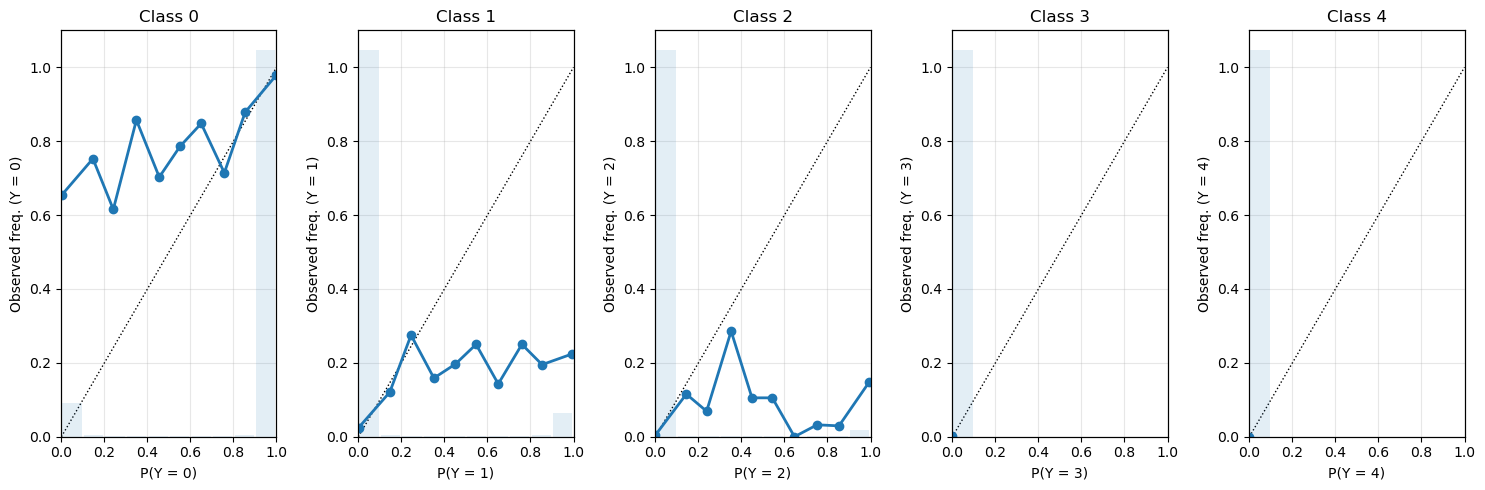

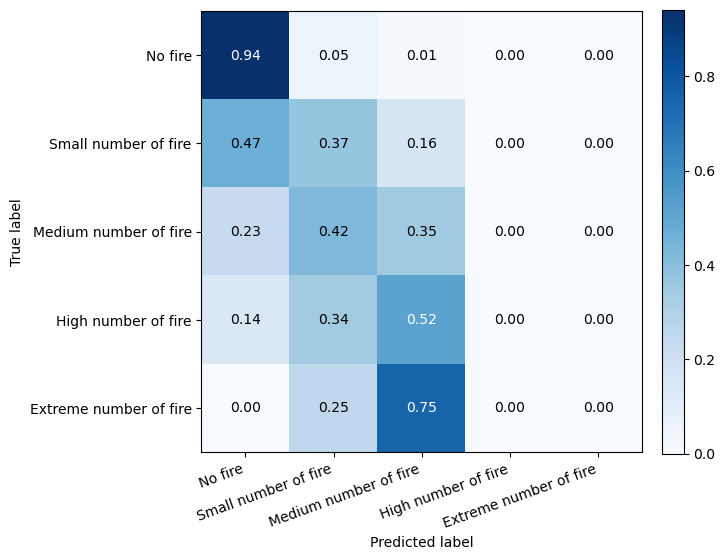

In [137]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"

models_type = ['GRU']

model = [f"{mt}_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss" for mt in models_type]
#model = "GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss"

pred = load_prediction(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    models=model,
    horizon=0,
)

target_name = 'nbsinister-kmeans-5-Class-Dept'
horizon = 0
cols = list([f'prediction_{target_name}_{horizon}_C{c}' for c in range(5)])

probs = pred.groupby(['date', 'graph_id'])[cols].mean().values
ytrue = pred.groupby(['date', 'graph_id'])[target_name].mean().values

print(ordinal_ece(probs, ytrue))
plot_calibration_with_background(probs, ytrue)
plt.show()

# df contient les colonnes: "Model", "y_true", "y_pred"
mean_cm, per_model = mean_confusion_by_model(
    pred,
    target_col=target_name,
    prediction_col=f'prediction_{target_name}_0',
    model_col="model",
    classes=[0,1,2,3,4],  # garantit l’ordre 0→4
    # labels peut être omis pour utiliser les libellés par défaut
    plot=True
)

/tmp/ipykernel_16147/4192341636.py:70: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


0.14408823684689587


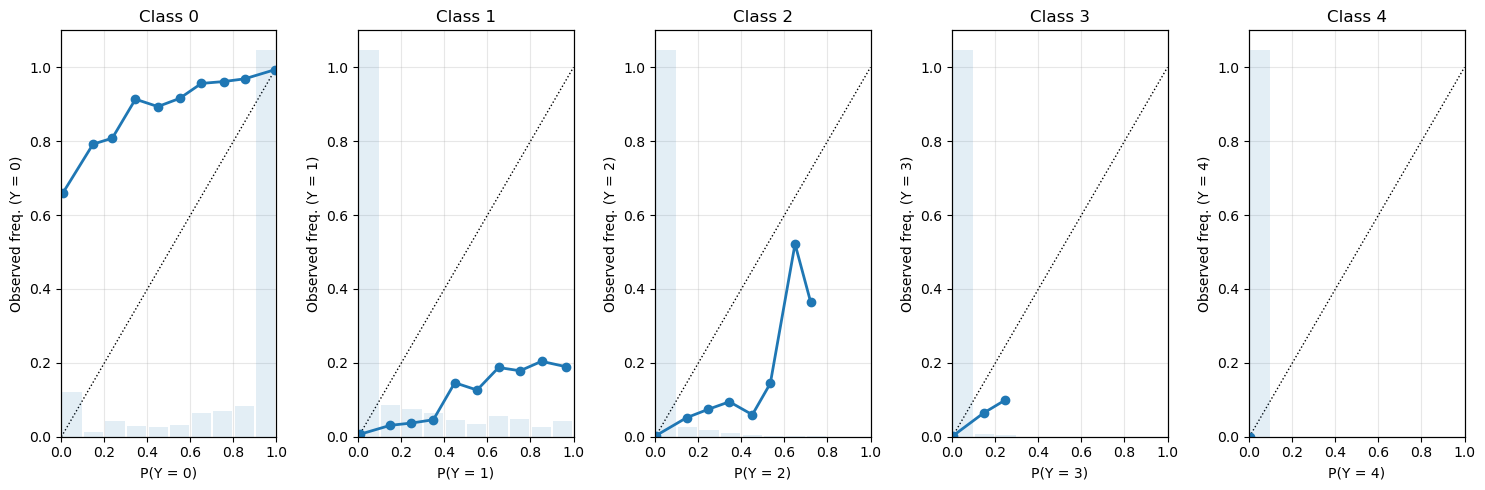

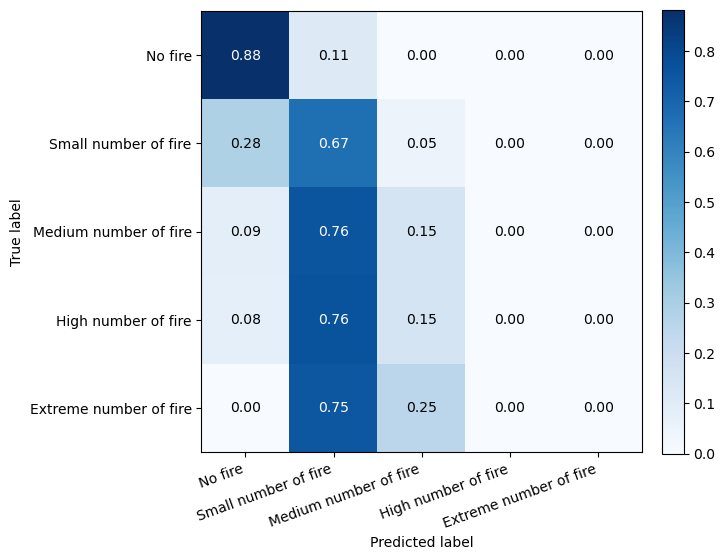

In [138]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"

models_type = ['filter-LSTM-soft-weight-10']

model = [f"{mt}_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss" for mt in models_type]
#model = "GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss"

pred = load_prediction(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    models=model,
    horizon=0,
)

target_name = 'nbsinister-kmeans-5-Class-Dept'
horizon = 0
cols = list([f'prediction_{target_name}_{horizon}_C{c}' for c in range(5)])

probs = pred.groupby(['date', 'graph_id'])[cols].mean().values
ytrue = pred.groupby(['date', 'graph_id'])[target_name].mean().values

print(ordinal_ece(probs, ytrue))
plot_calibration_with_background(probs, ytrue)
plt.show()

# df contient les colonnes: "Model", "y_true", "y_pred"
mean_cm, per_model = mean_confusion_by_model(
    pred,
    target_col=target_name,
    prediction_col=f'prediction_{target_name}_0',
    model_col="model",
    classes=[0,1,2,3,4],  # garantit l’ordre 0→4
    # labels peut être omis pour utiliser les libellés par défaut
    plot=True
)

In [139]:
df.Model.unique()

array(['studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-Confidence-T3.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-10',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-14',
       'studenMLP-RelationMLP-T6.0-A1.0-B1.0-filter-GRU-soft-weight-20',
       'filter-GRU-soft-weight-1', 'filter-GRU-soft-weight-2',
       'filter-GRU-soft-weight-3', 'filter-GRU-soft-weight-4',
       'filter-GRU-soft-weight-5', 'filter-GRU-soft-weight-6',
       'filter-GRU-soft-weight-7', 'filter-GRU-soft-weight-8',
       'filter-GRU-soft-weight-9', 'filter-GRU-soft-weight-10',
       'filter-GRU-soft-weight-11', 'filter-GRU-soft-weight-12',
       'filter-GRU-soft-weight-13', 'filter-GRU-soft-weight-14',
       'filter-GRU-soft-weight-15', 'filter-GRU-soft-weight-16',
       'filter-GRU-soft-weight-17', 'filter-GRU-soft-w

/tmp/ipykernel_16147/4192341636.py:70: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


0.08518431894725915


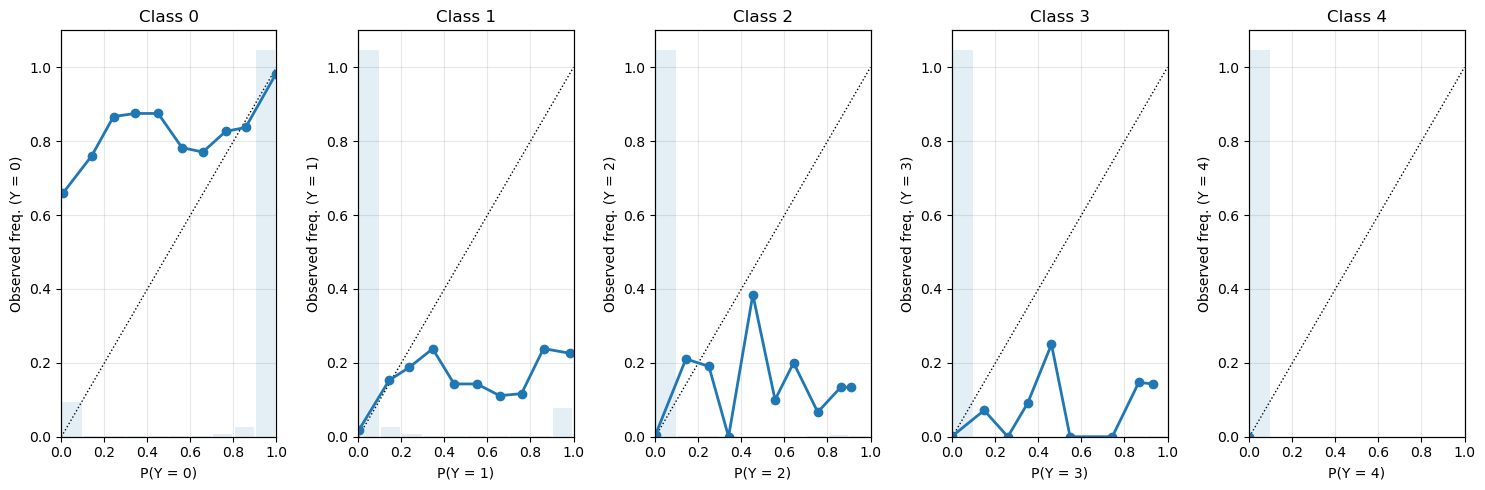

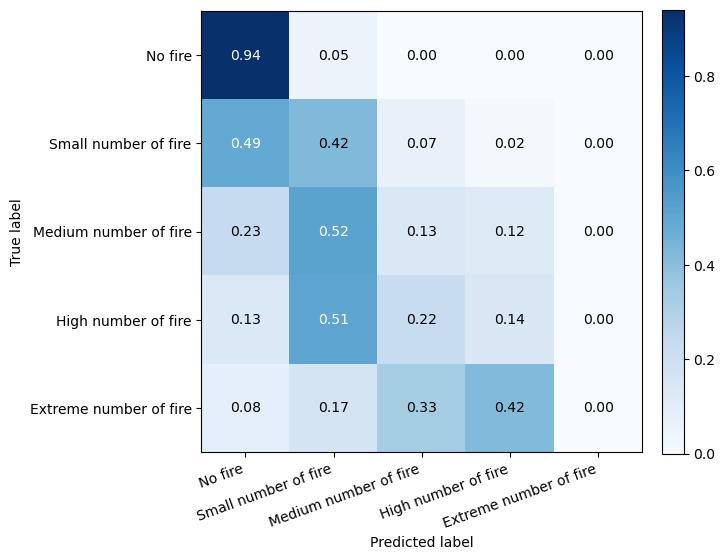

In [140]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"

models_type = ['studenMLP-normal-T3.0-A0.2-filter-GRU-soft-weight-10']

model = [f"{mt}_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss" for mt in models_type]
#model = "GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss"

pred = load_prediction(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    models=model,
    horizon=0,
)

target_name = 'nbsinister-kmeans-5-Class-Dept'
horizon = 0
cols = list([f'prediction_{target_name}_{horizon}_C{c}' for c in range(5)])

probs = pred.groupby(['date', 'graph_id'])[cols].mean().values
ytrue = pred.groupby(['date', 'graph_id'])[target_name].mean().values

print(ordinal_ece(probs, ytrue))
plot_calibration_with_background(probs, ytrue)
plt.show()

# df contient les colonnes: "Model", "y_true", "y_pred"
mean_cm, per_model = mean_confusion_by_model(
    pred,
    target_col=target_name,
    prediction_col=f'prediction_{target_name}_0',
    model_col="model",
    classes=[0,1,2,3,4],  # garantit l’ordre 0→4
    # labels peut être omis pour utiliser les libellés par défaut
    plot=True
)

/tmp/ipykernel_16147/4192341636.py:70: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


0.0834830303695087


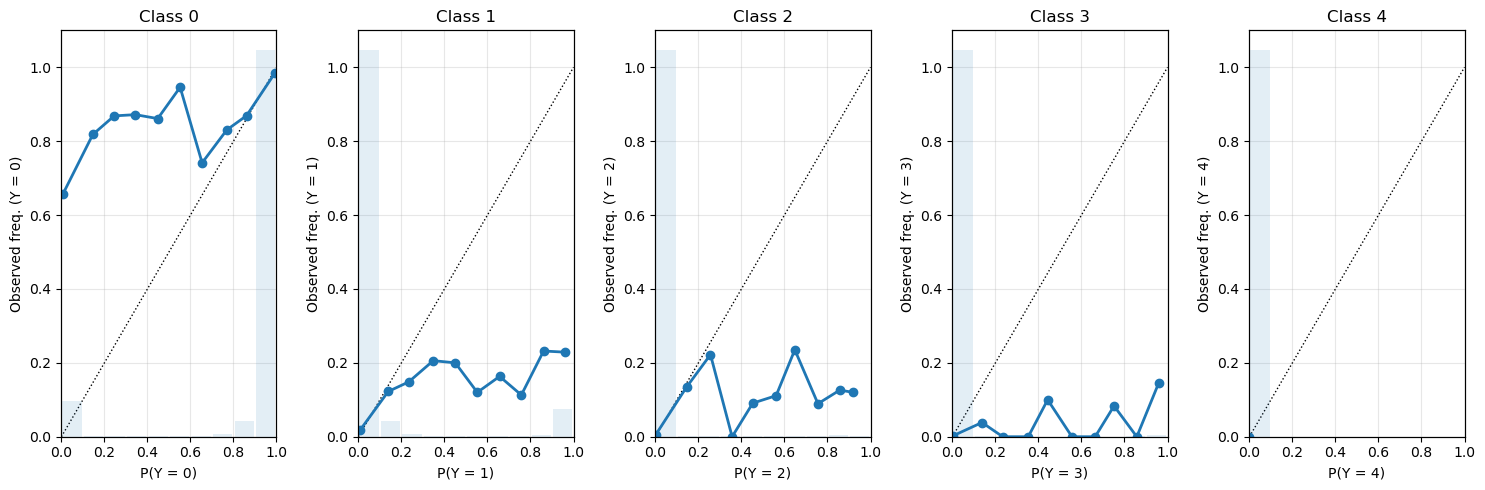

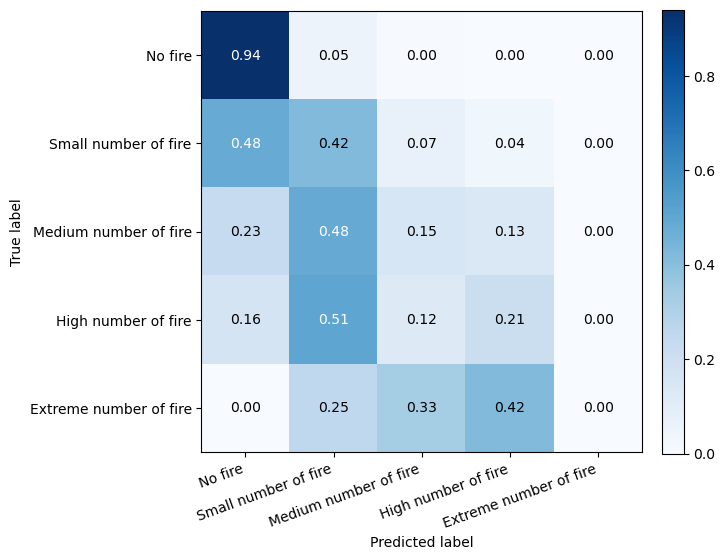

In [145]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"

models_type = ['studenMLP-normal-T3.0-A0.2-filter-GRU-soft-weight-20']

model = [f"{mt}_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss" for mt in models_type]
#model = "GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss"

pred = load_prediction(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    models=model,
    horizon=0,
)

target_name = 'nbsinister-kmeans-5-Class-Dept'
horizon = 0
cols = list([f'prediction_{target_name}_{horizon}_C{c}' for c in range(5)])

probs = pred.groupby(['date', 'graph_id'])[cols].mean().values
ytrue = pred.groupby(['date', 'graph_id'])[target_name].mean().values

print(ordinal_ece(probs, ytrue))
plot_calibration_with_background(probs, ytrue)
plt.show()

# df contient les colonnes: "Model", "y_true", "y_pred"
mean_cm, per_model = mean_confusion_by_model(
    pred,
    target_col=target_name,
    prediction_col=f'prediction_{target_name}_0',
    model_col="model",
    classes=[0,1,2,3,4],  # garantit l’ordre 0→4
    # labels peut être omis pour utiliser les libellés par défaut
    plot=True
)

In [141]:
"""TRAIN_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/train/"

dataset = load_train(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=TRAIN_DIR,
)"""

'TRAIN_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/train/"\n\ndataset = load_train(\n    ip=IP,\n    user=USER,\n    password=PASSWORD,\n    remote_dir=TRAIN_DIR,\n)'

In [142]:
import matplotlib.pyplot as plt

def plot_prediction(df, target_col, pred_col, date_col='date_str', step=30, figsize=(12, 4)):
    """
    Trace deux courbes : la vérité terrain (target_col) et la prédiction (pred_col)
    en utilisant df[date_col] comme axe des x, avec un pas d'étiquettes de 'step'.

    Paramètres
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes.
    target_col : str
        Nom de la colonne "ground truth".
    pred_col : str
        Nom de la colonne "prediction".
    date_col : str, optionnel (défaut: 'date_str')
        Nom de la colonne contenant les dates (au format string).
    step : int, optionnel (défaut: 30)
        Pas entre deux ticks (étiquettes) sur l’axe des x.
    figsize : tuple, optionnel (défaut: (12, 4))
        Taille de la figure matplotlib.

    Retour
    ------
    ax : matplotlib.axes.Axes
        L’axe sur lequel les courbes sont tracées.
    """
    # Vérifications simples
    for col in (target_col, pred_col, date_col):
        if col not in df.columns:
            raise ValueError(f"Colonne manquante dans le DataFrame: '{col}'")

    if len(df) == 0:
        raise ValueError("Le DataFrame est vide.")

    x = df[date_col].astype(str).values
    y_true = df[target_col].values
    y_pred = df[pred_col].values

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(y_true, label='Ground truth', linewidth=1.8)
    ax.plot(y_pred, label='Prediction', linewidth=1.8)

    # Ticks de l'axe des x tous les 'step' points
    n = len(df)
    tick_positions = list(range(0, n, max(1, step)))
    # S'assurer que le dernier point apparaît aussi si non multiple de step
    if tick_positions[-1] != n - 1:
        tick_positions.append(n - 1)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([x[i] for i in tick_positions], rotation=45, ha='right')

    ax.set_xlabel('Date')
    ax.set_ylabel("Class")
    ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.6)
    ax.legend()
    plt.tight_layout()

    return ax

def plot_class_vs_regression(df, target_col, pred_col, date_col='date_str', step=30, figsize=(12, 4)):
    """
    Trace deux courbes : la vérité terrain (target_col) et la prédiction (pred_col)
    en utilisant df[date_col] comme axe des x, avec un pas d'étiquettes de 'step'.

    Paramètres
    ----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes.
    target_col : str
        Nom de la colonne "ground truth".
    pred_col : str
        Nom de la colonne "prediction".
    date_col : str, optionnel (défaut: 'date_str')
        Nom de la colonne contenant les dates (au format string).
    step : int, optionnel (défaut: 30)
        Pas entre deux ticks (étiquettes) sur l’axe des x.
    figsize : tuple, optionnel (défaut: (12, 4))
        Taille de la figure matplotlib.

    Retour
    ------
    ax : matplotlib.axes.Axes
        L’axe sur lequel les courbes sont tracées.
    """
    # Vérifications simples
    for col in (target_col, pred_col, date_col):
        if col not in df.columns:
            raise ValueError(f"Colonne manquante dans le DataFrame: '{col}'")

    if len(df) == 0:
        raise ValueError("Le DataFrame est vide.")

    x = df[date_col].astype(str).values
    y_true = df[target_col].values
    y_pred = df[pred_col].values

    fig, ax = plt.subplots(2, figsize=figsize)

    ax[0].plot(y_true, label='Output classification', linewidth=1.8)
    ax[1].plot(y_pred, label='Number of fires', linewidth=1.8)

    # Ticks de l'axe des x tous les 'step' points
    n = len(df)
    tick_positions = list(range(0, n, max(1, step)))
    # S'assurer que le dernier point apparaît aussi si non multiple de step
    if tick_positions[-1] != n - 1:
        tick_positions.append(n - 1)
    
    ax[0].set_ylabel("Class")
    ax[1].set_ylabel("Fires")

    for i in range(2):
        ax[i].set_xticks(tick_positions)
        ax[i].set_xticklabels([x[i] for i in tick_positions], rotation=45, ha='right')

        ax[i].set_xlabel('Date')
        ax[i].grid(True, linestyle=':', linewidth=0.7, alpha=0.6)
        ax[i].legend()
    plt.tight_layout()
    
    return ax

<Axes: >

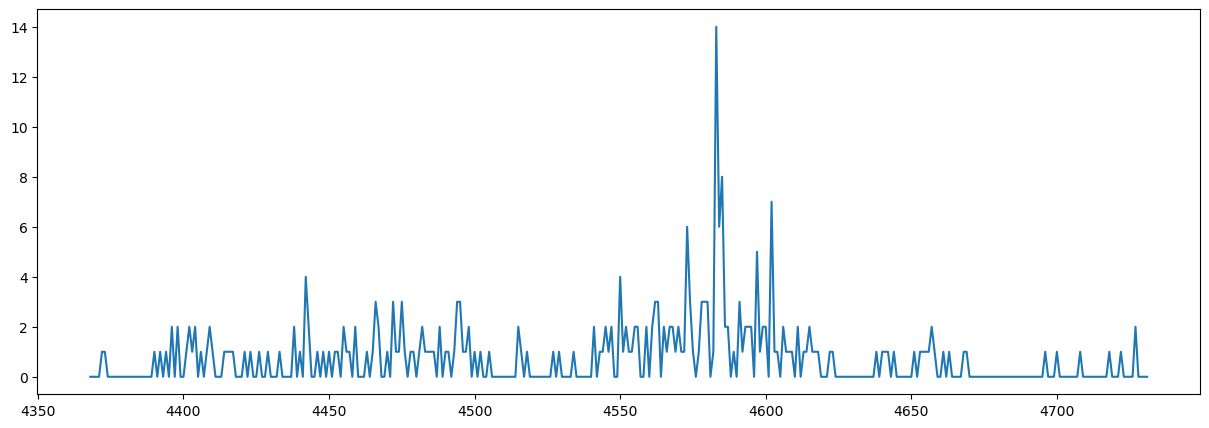

In [143]:
fig, ax = plt.subplots(1, figsize=(15,5))

pred[(pred['graph_id'] == 12) & (pred['model'] == pred['model'].iloc[0])]['nbsinister'].plot(ax=ax)

In [144]:
plot_prediction(pred[pred['graph_id'] == 12], 'nbsinister-kmeans-5-Class-Dept', 'prediction_nbsinister-kmeans-5-Class-Dept', step=100)

ValueError: Colonne manquante dans le DataFrame: 'prediction_nbsinister-kmeans-5-Class-Dept'

In [ ]:
dataset.departement.unique().shape, dataset.date.unique().shape, dataset[dataset['nbsinister'] > 0].date.unique().shape

((92,), (2758,), (2192,))

In [ ]:
dataset.shape

(253736, 468)